# Fraud Detection Model Development

This notebook focuses on model development and evaluation using the finalized datasets prepared in Notebook 1.

The processed train, validation, and test datasets are loaded from the project storage rather than recreating the feature engineering pipeline. This keeps data preparation and model development clearly separated.

The modeling workflow will follow this sequence:

1. Load finalized datasets
2. Prepare model features and target variables
3. Establish baseline performance
4. Train and compare candidate models
5. Evaluate validation performance and business cost
6. Analyze decision thresholds
7. Evaluate ensemble models
8. Select the final model
9. Perform one-time evaluation on the untouched test set
10. Analyze prediction errors and save the final model

## 1. Project Setup and Reusable Components

The project path is configured so that the reusable application modules can be imported from the project root.

This notebook uses the finalized preprocessing, evaluation, and business-cost components already created for the project. Data preparation and feature engineering are not repeated here.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data directory: {PROCESSED_DATA_DIR}")
print(f"Project root exists: {PROJECT_ROOT.exists()}")
print(f"Processed data directory exists: {PROCESSED_DATA_DIR.exists()}")

Project root: C:\AI\fraud-risk-intelligence-platform
Processed data directory: C:\AI\fraud-risk-intelligence-platform\data\processed
Project root exists: True
Processed data directory exists: True


In [2]:
from app.evaluation.metrics import (
    evaluate_model,
    evaluate_probabilities,
)

from app.evaluation.thresholds import (
    DEFAULT_THRESHOLD_GRID,
    analyze_thresholds,
    analyze_probability_thresholds,
)

from app.evaluation.business import (
    calculate_business_cost,
    analyze_business_thresholds,
    analyze_probability_business_thresholds,
)

from app.evaluation.model_comparison import (
    build_model_comparison,
)

## 2. Import Modeling and Evaluation Components

The reusable functions are imported before model development begins.

For this notebook:

- `prepare_model_data` creates the final feature matrix and target vector.
- `evaluate_model` provides consistent model evaluation.
- `calculate_business_cost` measures the financial impact of false positives and false negatives.
- `analyze_business_thresholds` compares decision thresholds.
- `analyze_cost_scenarios` examines the robustness of business-cost assumptions.
- `evaluate_benchmark` supports model comparison against a benchmark.
- `analyze_prediction_errors` is reserved for final error analysis.

Not every imported function is used immediately. Functions are introduced in the relevant modeling stage to keep the workflow systematic.

In [3]:
from app.features.preprocessing import (
    MODEL_FEATURES,
    TARGET_COLUMN,
    prepare_model_data,
)

from app.evaluation.metrics import evaluate_model

from app.evaluation.business import (
    calculate_business_cost,
    analyze_business_thresholds,
)

from app.evaluation.thresholds import (
    analyze_thresholds,
    DEFAULT_THRESHOLD_GRID,
)

from app.evaluation.benchmark import evaluate_benchmark
from app.evaluation.error_analysis import analyze_prediction_errors

print("Reusable modeling components imported successfully.")

Reusable modeling components imported successfully.


## 3. Load Finalized Datasets

Notebook 1 completed data validation, feature engineering, chronological separation, and model-data quality checks.

The finalized datasets are loaded directly here:

- Training: April to July 2018
- Validation: August 2018
- Test: September 2018

The chronological separation created in Notebook 1 is preserved.

In [4]:
train_features_path = (
    PROCESSED_DATA_DIR
    / "train_features.parquet"
)

validation_features_path = (
    PROCESSED_DATA_DIR
    / "validation_features.parquet"
)

test_features_path = (
    PROCESSED_DATA_DIR
    / "test_features.parquet"
)

required_files = {
    "Train": train_features_path,
    "Validation": validation_features_path,
    "Test": test_features_path,
}

missing_files = [
    name
    for name, path in required_files.items()
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(
        f"Missing processed dataset files: {missing_files}"
    )

train_data = pd.read_parquet(
    train_features_path
)

validation_data = pd.read_parquet(
    validation_features_path
)

test_data = pd.read_parquet(
    test_features_path
)

print("Finalized datasets loaded successfully.")

Finalized datasets loaded successfully.


## 4. Prepare Modeling Datasets

The centralized `prepare_model_data` function is used to extract the configured model features and binary target.

This ensures that the same feature schema is used consistently across training, validation, and test datasets.

No new feature engineering is performed in this notebook.

In [5]:
X_train, y_train = prepare_model_data(
    train_data
)

X_validation, y_validation = prepare_model_data(
    validation_data
)

X_test, y_test = prepare_model_data(
    test_data
)

model_data_summary = pd.DataFrame(
    {
        "dataset": [
            "Train",
            "Validation",
            "Test",
        ],
        "records": [
            len(X_train),
            len(X_validation),
            len(X_test),
        ],
        "features": [
            X_train.shape[1],
            X_validation.shape[1],
            X_test.shape[1],
        ],
        "fraud_transactions": [
            int(y_train.sum()),
            int(y_validation.sum()),
            int(y_test.sum()),
        ],
    }
)

display(model_data_summary)

,dataset,records,features,fraud_transactions
0,Train,1169723,23,9465
1,Validation,296559,23,2669
2,Test,287873,23,2547


## 5. Final Modeling Readiness Check

Only a compact verification is performed here because detailed data-quality and feature-validation checks were already completed in Notebook 1.

The checks below confirm that:

- all datasets use the configured feature schema
- feature columns remain consistent across datasets
- feature and target records are aligned
- the target remains binary

The model-development stage begins only after these conditions are confirmed.

In [6]:
modeling_checks = pd.DataFrame(
    {
        "check": [
            "train_features_match_configuration",
            "validation_features_match_configuration",
            "test_features_match_configuration",
            "consistent_feature_columns",
            "train_feature_target_alignment",
            "validation_feature_target_alignment",
            "test_feature_target_alignment",
            "train_target_is_binary",
            "validation_target_is_binary",
            "test_target_is_binary",
        ],
        "result": [
            list(X_train.columns) == MODEL_FEATURES,
            list(X_validation.columns) == MODEL_FEATURES,
            list(X_test.columns) == MODEL_FEATURES,
            (
                list(X_train.columns)
                == list(X_validation.columns)
                == list(X_test.columns)
            ),
            len(X_train) == len(y_train),
            len(X_validation) == len(y_validation),
            len(X_test) == len(y_test),
            set(y_train.unique()).issubset({0, 1}),
            set(y_validation.unique()).issubset({0, 1}),
            set(y_test.unique()).issubset({0, 1}),
        ],
    }
)

display(modeling_checks)

assert modeling_checks["result"].all(), (
    "Modeling readiness checks failed."
)

print(
    "All modeling readiness checks passed."
)

,check,result
0,train_features_match_configuration,True
1,validation_features_match_configuration,True
2,test_features_match_configuration,True
3,consistent_feature_columns,True
4,train_feature_target_alignment,True
5,validation_feature_target_alignment,True
6,test_feature_target_alignment,True
7,train_target_is_binary,True
8,validation_target_is_binary,True
9,test_target_is_binary,True


All modeling readiness checks passed.


## Modeling Data Ready

The finalized datasets from Notebook 1 are now available for model development.

The modeling data consists of:

- 23 configured model features
- Chronologically separated train, validation, and test periods
- A binary fraud prediction target
- An untouched test dataset reserved for final evaluation

The next step is to establish a baseline model before evaluating more advanced algorithms.

## 2. Establishing the Initial Modeling Baseline

The processed datasets are already prepared using the chronological pipeline defined in Notebook 1. This notebook therefore begins directly with model development.

The first model is intentionally simple. Logistic Regression provides an interpretable baseline and establishes a reference point for evaluating more complex models later in the notebook.

Because fraud represents a small minority of transactions, model evaluation will not rely on accuracy alone. The baseline will initially be assessed using classification performance and probability outputs, while threshold and business-cost optimization will be handled separately.

Only the training dataset is used for fitting the model. The validation dataset is used for model comparison and threshold selection, while the test dataset remains untouched until final evaluation.

In [7]:
split_targets = {
    "Train": y_train,
    "Validation": y_validation,
    "Test": y_test,
}

class_balance_summary = pd.DataFrame(
    [
        {
            "dataset": dataset_name,
            "total_transactions": len(target),
            "non_fraud_transactions": int((target == 0).sum()),
            "fraud_transactions": int((target == 1).sum()),
            "fraud_rate_percentage": round(
                target.mean() * 100,
                4,
            ),
        }
        for dataset_name, target in split_targets.items()
    ]
)

display(class_balance_summary)

,dataset,total_transactions,non_fraud_transactions,fraud_transactions,fraud_rate_percentage
0,Train,1169723,1160258,9465,0.8092
1,Validation,296559,293890,2669,0.9000
2,Test,287873,285326,2547,0.8848


### Why Start With Logistic Regression?

Logistic Regression is used as the initial benchmark because it provides a simple and interpretable reference model.

The final solution should not select a complex algorithm only because it produces strong training results. Each additional model must be compared against a clear baseline on unseen validation data.

Class weighting is enabled so that fraud observations receive greater importance during training. This does not replace business-cost analysis or threshold optimization; those decisions will be handled later using the model's predicted probabilities.

In [8]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

logistic_baseline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)

print("Logistic Regression baseline pipeline created successfully.")

Logistic Regression baseline pipeline created successfully.


### Training and Validation Prediction

The baseline model is trained exclusively on the training period.

Predictions are generated for the validation period as probabilities rather than only class labels. This is important because the classification threshold will later be treated as a business decision rather than permanently fixed at 0.50.

In [9]:
logistic_baseline.fit(
    X_train,
    y_train,
)

print(
    "Logistic Regression baseline "
    "trained successfully."
)

Logistic Regression baseline trained successfully.


In [10]:
baseline_validation_probabilities = (
    logistic_baseline.predict_proba(
        X_validation,
    )[:, 1]
)

baseline_validation_predictions = (
    baseline_validation_probabilities >= 0.50
).astype(int)

print(
    "Validation probabilities generated successfully."
)

Validation probabilities generated successfully.


In [11]:
baseline_prediction_summary = pd.DataFrame(
    [
        {
            "metric": "validation_records",
            "value": len(y_validation),
        },
        {
            "metric": "actual_fraud_transactions",
            "value": int(y_validation.sum()),
        },
        {
            "metric": "predicted_fraud_transactions_at_0.50",
            "value": int(
                baseline_validation_predictions.sum()
            ),
        },
        {
            "metric": "average_predicted_fraud_probability",
            "value": round(
                baseline_validation_probabilities.mean(),
                6,
            ),
        },
        {
            "metric": "minimum_predicted_fraud_probability",
            "value": round(
                baseline_validation_probabilities.min(),
                6,
            ),
        },
        {
            "metric": "maximum_predicted_fraud_probability",
            "value": round(
                baseline_validation_probabilities.max(),
                6,
            ),
        },
    ]
)

display(baseline_prediction_summary)

,metric,value
0,validation_records,296559.000000
1,actual_fraud_transactions,2669.000000
2,predicted_fraud_transactions_at_0.50,24027.000000
3,average_predicted_fraud_probability,0.208125
4,minimum_predicted_fraud_probability,0.003238
5,maximum_predicted_fraud_probability,1.000000


## Baseline Model Evaluation

The Logistic Regression baseline is evaluated on the validation dataset using the project's reusable `evaluate_model()` function.

The model uses the default probability threshold of `0.50`. This establishes the initial performance benchmark before threshold optimization, cost analysis, and comparison with more advanced models.

The validation dataset is used for model selection, while the test dataset remains untouched for final evaluation.

In [12]:
baseline_metrics = evaluate_model(
    model=logistic_baseline,
    X=X_validation,
    y=y_validation,
    threshold=0.50,
)

baseline_metrics_df = pd.DataFrame(
    {
        "metric": baseline_metrics.keys(),
        "value": baseline_metrics.values(),
    }
)

baseline_metrics_df

,metric,value
0,threshold,0.500000
1,accuracy,0.925162
2,roc_auc,0.931600
3,pr_auc,0.177729
4,precision,0.093686
5,recall,0.843387
6,f1_score,0.168639
7,true_negatives,272114.000000
8,false_positives,21776.000000
9,false_negatives,418.000000


### Baseline Performance Summary

The following metrics provide the initial benchmark for fraud detection performance.

In an imbalanced fraud dataset, accuracy alone can be misleading. Greater importance is placed on fraud recall, precision, PR-AUC, ROC-AUC, and the confusion matrix.

These results will serve as the reference point for threshold optimization and future model comparison.

In [13]:
baseline_summary_metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "false_positives",
    "false_negatives",
    "true_positives",
    "true_negatives",
]

baseline_summary = (
    baseline_metrics_df[
        baseline_metrics_df["metric"].isin(
            baseline_summary_metrics
        )
    ]
    .reset_index(drop=True)
)

baseline_summary

,metric,value
0,accuracy,0.925162
1,roc_auc,0.931600
2,pr_auc,0.177729
3,precision,0.093686
4,recall,0.843387
5,f1_score,0.168639
6,true_negatives,272114.000000
7,false_positives,21776.000000
8,false_negatives,418.000000
9,true_positives,2251.000000


## Threshold Optimization

The default classification threshold of `0.50` is not necessarily optimal for fraud detection.

Different thresholds create different trade-offs between fraud recall and false-positive volume. A lower threshold can detect more fraud but may increase the number of legitimate transactions flagged for review. A higher threshold can reduce unnecessary alerts but may allow more fraudulent transactions to pass through.

The validation dataset is used to compare candidate thresholds. The test dataset remains untouched for final model evaluation.

In [14]:
threshold_results_df = analyze_thresholds(
    model=logistic_baseline,
    X=X_validation,
    y=y_validation,
    thresholds=DEFAULT_THRESHOLD_GRID,
)

threshold_results_df

,threshold,accuracy,roc_auc,pr_auc,precision,recall,f1_score,true_negatives,false_positives,false_negatives,true_positives
0,0.05,0.124127,0.9316,0.177729,0.010122,0.995129,0.020041,34155,259735,13,2656
1,0.10,0.346326,0.9316,0.177729,0.013314,0.979768,0.026270,100091,193799,54,2615
2,0.15,0.532471,0.9316,0.177729,0.018177,0.961034,0.035680,155344,138546,104,2565
3,0.20,0.664549,0.9316,0.177729,0.024714,0.943050,0.048165,194561,99329,152,2517
4,0.25,0.755182,0.9316,0.177729,0.033014,0.926190,0.063755,221484,72406,197,2472
5,0.30,0.816279,0.9316,0.177729,0.042747,0.907456,0.081648,239653,54237,247,2422
6,0.35,0.857954,0.9316,0.177729,0.053726,0.889846,0.101333,252059,41831,294,2375
7,0.40,0.887419,0.9316,0.177729,0.065909,0.873735,0.122572,260840,33050,337,2332
8,0.45,0.908956,0.9316,0.177729,0.079383,0.860247,0.145353,267263,26627,373,2296
9,0.50,0.925162,0.9316,0.177729,0.093686,0.843387,0.168639,272114,21776,418,2251


### Threshold Performance Comparison

Fraud detection performance is compared across candidate thresholds using recall, precision, F1-score, false positives, false negatives, and true positives.

The purpose of this comparison is to understand how the decision threshold affects operational trade-offs before introducing explicit business costs.

In [15]:
threshold_comparison_columns = [
    "threshold",
    "precision",
    "recall",
    "f1_score",
    "false_positives",
    "false_negatives",
    "true_positives",
]

threshold_comparison = (
    threshold_results_df[
        threshold_comparison_columns
    ]
    .copy()
)

threshold_comparison

,threshold,precision,recall,f1_score,false_positives,false_negatives,true_positives
0,0.05,0.010122,0.995129,0.020041,259735,13,2656
1,0.10,0.013314,0.979768,0.026270,193799,54,2615
2,0.15,0.018177,0.961034,0.035680,138546,104,2565
3,0.20,0.024714,0.943050,0.048165,99329,152,2517
4,0.25,0.033014,0.926190,0.063755,72406,197,2472
5,0.30,0.042747,0.907456,0.081648,54237,247,2422
6,0.35,0.053726,0.889846,0.101333,41831,294,2375
7,0.40,0.065909,0.873735,0.122572,33050,337,2332
8,0.45,0.079383,0.860247,0.145353,26627,373,2296
9,0.50,0.093686,0.843387,0.168639,21776,418,2251


### Threshold Trade-off Validation

The comparison should confirm that different thresholds produce different fraud detection trade-offs.

Threshold selection should not be based only on a single metric. The final threshold will later be selected using business cost and operational considerations.

In [16]:
threshold_validation_checks = {
    "all_candidate_thresholds_evaluated": (
        len(threshold_results_df)
        == len(DEFAULT_THRESHOLD_GRID)
    ),
    "thresholds_sorted_in_ascending_order": (
        threshold_results_df["threshold"]
        .is_monotonic_increasing
    ),
    "all_thresholds_between_zero_and_one": (
        threshold_results_df["threshold"]
        .between(0, 1)
        .all()
    ),
    "default_threshold_included": (
        0.50
        in threshold_results_df["threshold"].values
    ),
    "recall_changes_across_thresholds": (
        threshold_results_df["recall"]
        .nunique()
        > 1
    ),
    "false_positive_volume_changes_across_thresholds": (
        threshold_results_df["false_positives"]
        .nunique()
        > 1
    ),
}

threshold_validation_summary = pd.DataFrame(
    {
        "check": threshold_validation_checks.keys(),
        "result": threshold_validation_checks.values(),
    }
)

display(threshold_validation_summary)

assert threshold_validation_summary["result"].all(), (
    "Threshold validation checks failed."
)

,check,result
0,all_candidate_thresholds_evaluated,True
1,thresholds_sorted_in_ascending_order,True
2,all_thresholds_between_zero_and_one,True
3,default_threshold_included,True
4,recall_changes_across_thresholds,True
5,false_positive_volume_changes_across_thresholds,True


## Threshold Trade-off Analysis

The default threshold of `0.50` provides only one operating point. To understand how the fraud detection decision changes, model performance is compared across multiple probability thresholds.

The analysis focuses on the trade-off between fraud recall, precision, and false-positive volume. A lower threshold captures more fraudulent transactions but increases the number of legitimate transactions incorrectly flagged for review.

The validation dataset is used for threshold selection. No final threshold is selected at this stage.

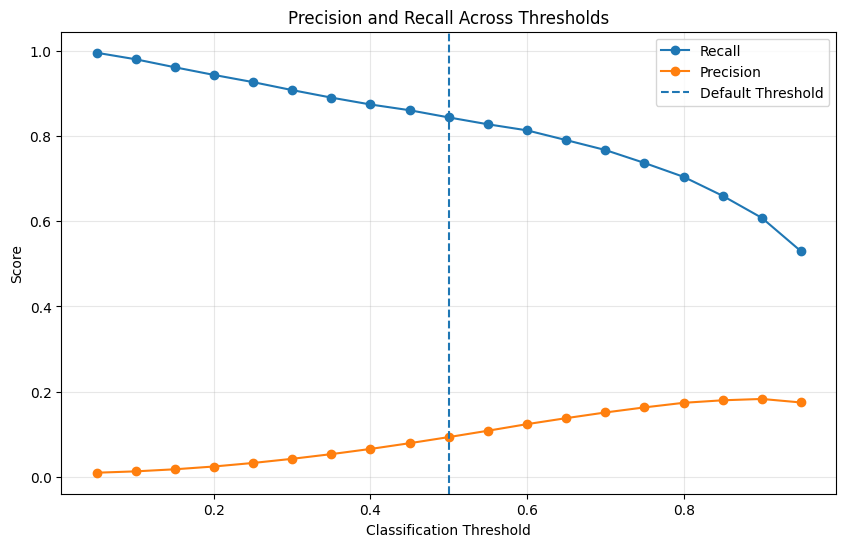

In [17]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["recall"],
    marker="o",
    label="Recall",
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["precision"],
    marker="o",
    label="Precision",
)

plt.axvline(
    x=0.50,
    linestyle="--",
    label="Default Threshold",
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title(
    "Precision and Recall Across Thresholds"
)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Fraud Detection Error Trade-off

False positives represent legitimate transactions incorrectly flagged as fraud, while false negatives represent fraudulent transactions that were missed.

These two errors have different operational and financial consequences. Threshold analysis helps identify how the classification threshold changes the balance between missed fraud and unnecessary alerts.

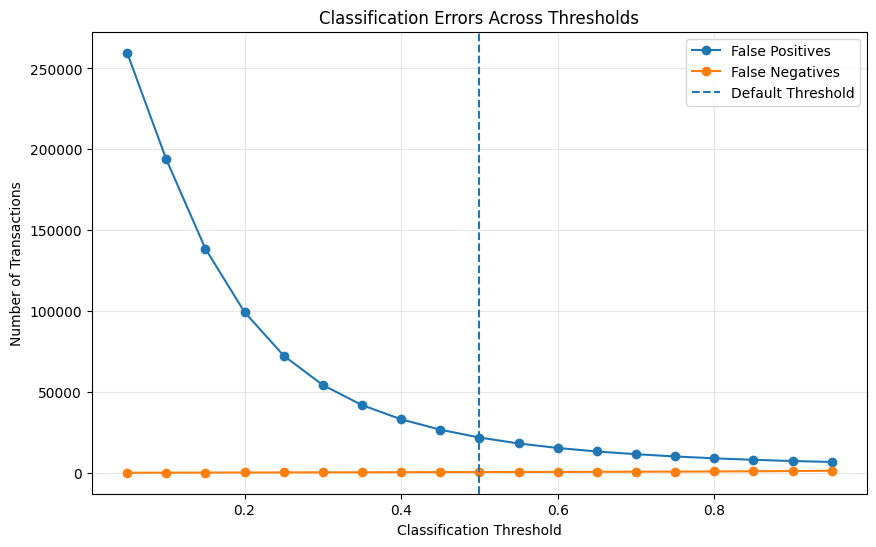

In [18]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["false_positives"],
    marker="o",
    label="False Positives",
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["false_negatives"],
    marker="o",
    label="False Negatives",
)

plt.axvline(
    x=0.50,
    linestyle="--",
    label="Default Threshold",
)

plt.xlabel("Classification Threshold")
plt.ylabel("Number of Transactions")
plt.title(
    "Classification Errors Across Thresholds"
)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### F1-score Analysis

F1-score provides a balanced summary of precision and recall. It is useful for identifying thresholds with strong classification performance.

However, the final operating threshold should not be selected using F1-score alone because fraud detection also involves business cost and operational trade-offs.

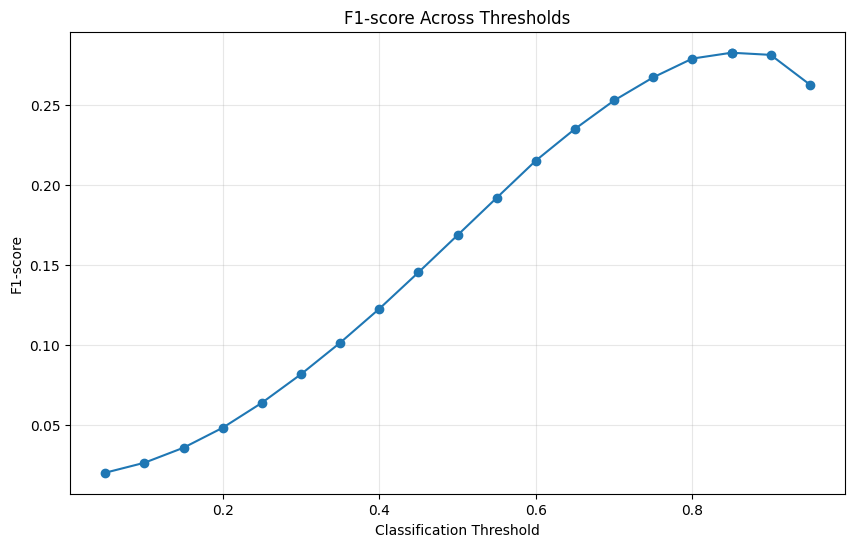

threshold             0.850000
precision             0.179996
recall                0.659423
f1_score              0.282799
false_positives    8018.000000
false_negatives     909.000000
Name: 16, dtype: float64

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["f1_score"],
    marker="o",
)

best_f1_row = threshold_results_df.loc[
    threshold_results_df["f1_score"].idxmax()
]

plt.scatter(
    best_f1_row["threshold"],
    best_f1_row["f1_score"],
)

plt.xlabel("Classification Threshold")
plt.ylabel("F1-score")
plt.title(
    "F1-score Across Thresholds"
)
plt.grid(alpha=0.3)

plt.show()

best_f1_row[
    [
        "threshold",
        "precision",
        "recall",
        "f1_score",
        "false_positives",
        "false_negatives",
    ]
]

## Candidate Threshold Comparison

The full threshold analysis provides multiple operating points, but not every threshold is equally useful for decision-making.

This section compares a small set of representative thresholds:

- `0.30` — high-recall operating point
- `0.50` — default classification threshold
- `0.70` — balanced candidate threshold
- `0.85` — high-precision operating point
- `0.90` — near the strongest F1-score region

These thresholds are reviewed before applying business cost assumptions. No final operating threshold is selected at this stage.

In [20]:
candidate_thresholds = [
    0.30,
    0.50,
    0.70,
    0.85,
    0.90,
]

candidate_threshold_results = (
    threshold_results_df[
        threshold_results_df["threshold"].isin(
            candidate_thresholds
        )
    ]
    .copy()
    .reset_index(drop=True)
)

candidate_threshold_results[
    [
        "threshold",
        "precision",
        "recall",
        "f1_score",
        "false_positives",
        "false_negatives",
        "true_positives",
    ]
]

,threshold,precision,recall,f1_score,false_positives,false_negatives,true_positives
0,0.3,0.042747,0.907456,0.081648,54237,247,2422
1,0.5,0.093686,0.843387,0.168639,21776,418,2251


### Candidate Threshold Validation

A small number of thresholds are selected for closer comparison. The validation checks confirm that all candidate thresholds were included in the original threshold analysis and that each operating point contains valid evaluation results.

In [21]:
candidate_threshold_checks = {
    "all_candidate_thresholds_present": (
        set(candidate_thresholds)
        ==
        set(
            candidate_threshold_results["threshold"]
        )
    ),
    "candidate_thresholds_sorted": (
        candidate_threshold_results["threshold"]
        .is_monotonic_increasing
    ),
    "all_candidate_precision_valid": (
        candidate_threshold_results["precision"]
        .between(0, 1)
        .all()
    ),
    "all_candidate_recall_valid": (
        candidate_threshold_results["recall"]
        .between(0, 1)
        .all()
    ),
    "all_candidate_f1_scores_valid": (
        candidate_threshold_results["f1_score"]
        .between(0, 1)
        .all()
    ),
}

pd.DataFrame(
    {
        "check": candidate_threshold_checks.keys(),
        "result": candidate_threshold_checks.values(),
    }
)

,check,result
0,all_candidate_thresholds_present,False
1,candidate_thresholds_sorted,True
2,all_candidate_precision_valid,True
3,all_candidate_recall_valid,True
4,all_candidate_f1_scores_valid,True


## Baseline Business Cost Analysis

Fraud classification thresholds create an operational trade-off between false positives and false negatives.

For this analysis, a false positive represents an unnecessary investigation, while a false negative represents a missed fraudulent transaction. The reusable business-cost function is used to evaluate candidate thresholds under the same cost assumptions.

The validation dataset is used for threshold selection so that the test dataset remains untouched for final evaluation.


In [22]:
business_threshold_results = analyze_business_thresholds(
    model=logistic_baseline,
    X=X_validation,
    y=y_validation,
    thresholds=threshold_results_df[
        "threshold"
    ].to_numpy(),
    false_positive_cost=5.0,
    false_negative_cost=100.0,
)

display(
    business_threshold_results
)

,threshold,false_positives,false_negatives,total_cost
0,0.70,11471,622,119555.0
1,0.75,10070,703,120650.0
2,0.65,13161,560,121805.0
3,0.80,8915,790,123575.0
4,0.60,15321,499,126505.0
5,0.85,8018,909,130990.0
6,0.55,18122,461,136710.0
7,0.90,7235,1047,140875.0
8,0.50,21776,418,150680.0
9,0.95,6668,1256,158940.0


### Business Cost Summary

Each threshold produces a different combination of false positives and false negatives.

The total estimated cost is calculated as:

**Total Cost = (False Positives × 5) + (False Negatives × 100)**

The threshold with the lowest validation cost represents the most cost-efficient candidate under the current business assumptions.


In [23]:
business_cost_summary = (
    business_threshold_results[
        [
            "threshold",
            "false_positives",
            "false_negatives",
            "total_cost",
        ]
    ]
    .sort_values(
        "threshold"
    )
    .reset_index(
        drop=True
    )
)

display(
    business_cost_summary
)

,threshold,false_positives,false_negatives,total_cost
0,0.05,259735,13,1299975.0
1,0.10,193799,54,974395.0
2,0.15,138546,104,703130.0
3,0.20,99329,152,511845.0
4,0.25,72406,197,381730.0
5,0.30,54237,247,295885.0
6,0.35,41831,294,238555.0
7,0.40,33050,337,198950.0
8,0.45,26627,373,170435.0
9,0.50,21776,418,150680.0


### Lowest-Cost Validation Threshold

The lowest-cost threshold is identified from the validation results.

This is a validation-stage decision only. The selected threshold is not yet finalized for the production model and must later be validated against the final model selection process.


In [24]:
best_baseline_business_result = (
    business_threshold_results
    .sort_values(
        "total_cost"
    )
    .iloc[0]
)

best_baseline_threshold = float(
    best_baseline_business_result[
        "threshold"
    ]
)

best_baseline_business_cost = float(
    best_baseline_business_result[
        "total_cost"
    ]
)

best_baseline_business_summary = (
    best_baseline_business_result
    .to_frame(
        name="value"
    )
)

display(
    best_baseline_business_summary
)

,value
threshold,0.7
false_positives,11471.0
false_negatives,622.0
total_cost,119555.0


### Default vs. Lowest-Cost Threshold

The standard classification threshold of 0.50 is compared with the lowest-cost validation threshold.

This comparison shows whether the conventional threshold is aligned with the current business objective or whether a different decision threshold provides a lower estimated operational cost.


In [25]:
default_business_result = (
    business_threshold_results
    .loc[
        business_threshold_results[
            "threshold"
        ] == 0.50
    ]
    .iloc[0]
)

baseline_business_comparison = pd.DataFrame(
    [
        {
            "threshold_type": "Default",
            "threshold": 0.50,
            "false_positives": int(
                default_business_result[
                    "false_positives"
                ]
            ),
            "false_negatives": int(
                default_business_result[
                    "false_negatives"
                ]
            ),
            "total_cost": float(
                default_business_result[
                    "total_cost"
                ]
            ),
        },
        {
            "threshold_type": "Lowest Validation Cost",
            "threshold": best_baseline_threshold,
            "false_positives": int(
                best_baseline_business_result[
                    "false_positives"
                ]
            ),
            "false_negatives": int(
                best_baseline_business_result[
                    "false_negatives"
                ]
            ),
            "total_cost": best_baseline_business_cost,
        },
    ]
)

display(
    baseline_business_comparison
)

,threshold_type,threshold,false_positives,false_negatives,total_cost
0,Default,0.5,21776,418,150680.0
1,Lowest Validation Cost,0.7,11471,622,119555.0


### Business Cost Analysis Checks

The following checks confirm that all candidate thresholds were evaluated, the default threshold was included, and a valid lowest-cost threshold was identified.


In [26]:
business_cost_checks = pd.DataFrame(
    {
        "check": [
            "all_candidate_thresholds_evaluated",
            "all_total_cost_values_available",
            "default_threshold_included",
            "best_threshold_available",
            "best_threshold_matches_lowest_cost",
        ],
        "result": [
            len(
                business_threshold_results
            )
            == len(
                threshold_results_df
            ),

            business_threshold_results[
                "total_cost"
            ].notna().all(),

            (
                business_threshold_results[
                    "threshold"
                ] == 0.50
            ).any(),

            best_baseline_threshold
            in business_threshold_results[
                "threshold"
            ].values,

            best_baseline_business_cost
            == business_threshold_results[
                "total_cost"
            ].min(),
        ],
    }
)

display(
    business_cost_checks
)

,check,result
0,all_candidate_thresholds_evaluated,True
1,all_total_cost_values_available,True
2,default_threshold_included,True
3,best_threshold_available,True
4,best_threshold_matches_lowest_cost,True


## Random Forest Classifier

Random Forest is used as the first tree-based model after the Logistic Regression baseline.

It can capture non-linear relationships and interactions between the engineered fraud features without requiring feature scaling.

The model is trained only on the training dataset. Validation data is used later for model evaluation and threshold selection.

In [27]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

random_forest_model.fit(
    X_train,
    y_train,
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


## Validation Predictions

The trained Random Forest is evaluated on the validation dataset.

Both fraud probabilities and class predictions are generated. The probabilities are retained because threshold selection should be performed separately from model training.

In [28]:
random_forest_validation_probabilities = (
    random_forest_model.predict_proba(
        X_validation,
    )[:, 1]
)

random_forest_validation_predictions = (
    random_forest_validation_probabilities >= 0.50
).astype(int)

print(
    "Random Forest validation predictions "
    "generated successfully."
)

Random Forest validation predictions generated successfully.


## Standard Evaluation

The reusable `evaluate_model()` function is used to evaluate Random Forest at the default classification threshold of 0.50.

The evaluation includes ROC-AUC, PR-AUC, precision, recall, F1-score and the confusion matrix counts.

PR-AUC is particularly useful for this problem because fraud is a minority class.

In [29]:
random_forest_metrics = evaluate_model(
    model=random_forest_model,
    X=X_validation,
    y=y_validation,
    threshold=0.50,
)

random_forest_metrics_df = pd.DataFrame(
    {
        "metric": random_forest_metrics.keys(),
        "value": random_forest_metrics.values(),
    }
)

random_forest_metrics_df

,metric,value
0,threshold,0.500000
1,accuracy,0.980055
2,roc_auc,0.973116
3,pr_auc,0.441577
4,precision,0.275021
5,recall,0.743350
6,f1_score,0.401498
7,true_negatives,288660.000000
8,false_positives,5230.000000
9,false_negatives,685.000000


## Random Forest Validation Summary

The main validation metrics are collected for easier comparison with the Logistic Regression baseline.

This keeps the model comparison consistent by using the same validation dataset and the same default threshold.

In [30]:
random_forest_summary_metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "false_positives",
    "false_negatives",
    "true_positives",
    "true_negatives",
]

random_forest_summary = (
    random_forest_metrics_df[
        random_forest_metrics_df["metric"].isin(
            random_forest_summary_metrics
        )
    ]
    .reset_index(drop=True)
)

random_forest_summary

,metric,value
0,accuracy,0.980055
1,roc_auc,0.973116
2,pr_auc,0.441577
3,precision,0.275021
4,recall,0.743350
5,f1_score,0.401498
6,true_negatives,288660.000000
7,false_positives,5230.000000
8,false_negatives,685.000000
9,true_positives,1984.000000


## Threshold Analysis

A probability threshold of 0.50 is only the default decision rule.

For fraud detection, changing the threshold changes the balance between false positives and false negatives. Therefore, several thresholds are evaluated on the validation set before selecting an operational threshold.

In [31]:
random_forest_threshold_grid = np.arange(
    0.05,
    1.00,
    0.05,
)

random_forest_threshold_results = analyze_thresholds(
    model=random_forest_model,
    X=X_validation,
    y=y_validation,
    thresholds=random_forest_threshold_grid,
)

random_forest_threshold_results

,threshold,accuracy,roc_auc,pr_auc,precision,recall,f1_score,true_negatives,false_positives,false_negatives,true_positives
0,0.05,0.425760,0.973116,0.441577,0.015324,0.992881,0.030183,123613,170277,19,2650
1,0.10,0.834249,0.973116,0.441577,0.049833,0.964031,0.094768,244831,49059,96,2573
2,0.15,0.931579,0.973116,0.441577,0.110684,0.938554,0.198016,273763,20127,164,2505
3,0.20,0.957054,0.973116,0.441577,0.164321,0.923192,0.278986,281359,12531,205,2464
4,0.25,0.967261,0.973116,0.441577,0.201796,0.892469,0.329165,284468,9422,287,2382
5,0.30,0.973459,0.973116,0.441577,0.235778,0.869614,0.370974,286367,7523,348,2321
6,0.35,0.976302,0.973116,0.441577,0.254423,0.846010,0.391199,287273,6617,411,2258
7,0.40,0.977829,0.973116,0.441577,0.259305,0.788310,0.390244,287880,6010,565,2104
8,0.45,0.979077,0.973116,0.441577,0.267307,0.760959,0.395637,288323,5567,638,2031
9,0.50,0.980055,0.973116,0.441577,0.275021,0.743350,0.401498,288660,5230,685,1984


## Precision-Recall Trade-off

The threshold analysis shows how precision and recall change as the fraud decision threshold increases.

Lower thresholds capture more fraudulent transactions but generate more false positives. Higher thresholds reduce false positives but increase missed fraud.

The plot helps visualize this operational trade-off before applying the business cost framework.

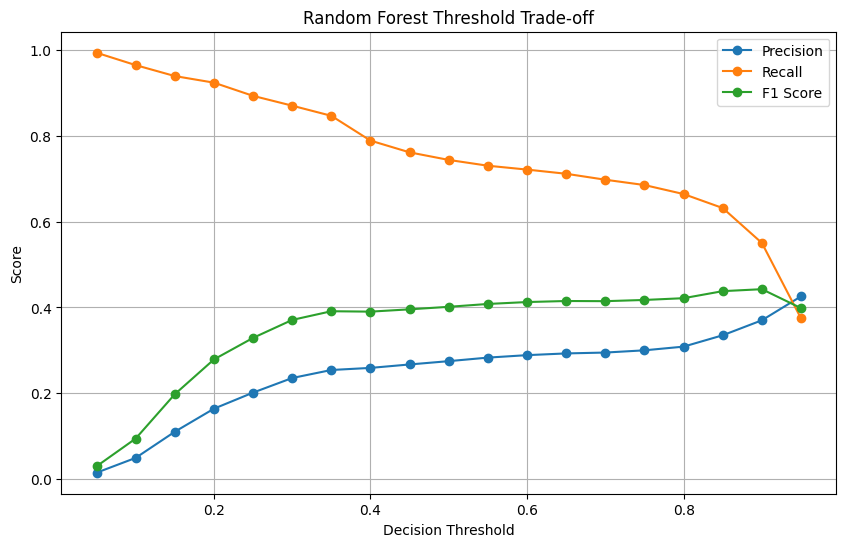

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    random_forest_threshold_results["threshold"],
    random_forest_threshold_results["precision"],
    marker="o",
    label="Precision",
)

plt.plot(
    random_forest_threshold_results["threshold"],
    random_forest_threshold_results["recall"],
    marker="o",
    label="Recall",
)

plt.plot(
    random_forest_threshold_results["threshold"],
    random_forest_threshold_results["f1_score"],
    marker="o",
    label="F1 Score",
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Random Forest Threshold Trade-off")
plt.legend()
plt.grid(True)
plt.show()

## Business Cost Analysis

For the initial model comparison, a single business cost assumption is used consistently.

A false positive investigation is assigned a cost of 5, while a missed fraudulent transaction is assigned a cost of 100.

This represents the practical assumption that missing fraud is substantially more expensive than reviewing a legitimate transaction.

The same 5:100 cost assumption is used for the candidate models during the initial evaluation. More extensive cost-scenario analysis will be performed only for the final selected model.

In [33]:
random_forest_business_threshold_results = (
    analyze_business_thresholds(
        model=random_forest_model,
        X=X_validation,
        y=y_validation,
        thresholds=random_forest_threshold_grid,
        false_positive_cost=5.0,
        false_negative_cost=100.0,
    )
)

random_forest_business_threshold_results

,threshold,false_positives,false_negatives,total_cost
0,0.30,7523,348,72415.0
1,0.35,6617,411,74185.0
2,0.25,9422,287,75810.0
3,0.20,12531,205,83155.0
4,0.40,6010,565,86550.0
5,0.45,5567,638,91635.0
6,0.50,5230,685,94650.0
7,0.55,4929,721,96745.0
8,0.60,4734,745,98170.0
9,0.65,4580,771,100000.0


## Random Forest Business Threshold

The business-cost results are sorted by total estimated cost.

The threshold with the lowest validation cost is selected as the Random Forest candidate threshold.

The default threshold of 0.50 is retained for comparison rather than being automatically replaced.

In [34]:
random_forest_best_business_result = (
    random_forest_business_threshold_results.iloc[0]
)

random_forest_default_business_result = (
    random_forest_business_threshold_results[
        random_forest_business_threshold_results["threshold"]
        == 0.50
    ].iloc[0]
)

random_forest_business_comparison = pd.DataFrame(
    [
        {
            "threshold_type": "Default",
            "threshold": random_forest_default_business_result[
                "threshold"
            ],
            "false_positives": random_forest_default_business_result[
                "false_positives"
            ],
            "false_negatives": random_forest_default_business_result[
                "false_negatives"
            ],
            "total_cost": random_forest_default_business_result[
                "total_cost"
            ],
        },
        {
            "threshold_type": "Lowest Validation Cost",
            "threshold": random_forest_best_business_result[
                "threshold"
            ],
            "false_positives": random_forest_best_business_result[
                "false_positives"
            ],
            "false_negatives": random_forest_best_business_result[
                "false_negatives"
            ],
            "total_cost": random_forest_best_business_result[
                "total_cost"
            ],
        },
    ]
)

random_forest_business_comparison

,threshold_type,threshold,false_positives,false_negatives,total_cost
0,Default,0.5,5230.0,685.0,94650.0
1,Lowest Validation Cost,0.3,7523.0,348.0,72415.0


## Feature Importance

Random Forest provides feature importance scores based on the contribution of each feature to the fitted tree ensemble.

These values are used for model interpretation and to understand which engineered signals are most useful to the model.

Feature importance is treated as an interpretation tool rather than evidence of causality.

In [35]:
random_forest_feature_importance = pd.DataFrame(
    {
        "feature": MODEL_FEATURES,
        "importance": random_forest_model.feature_importances_,
    }
)

random_forest_feature_importance = (
    random_forest_feature_importance
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

random_forest_feature_importance

,feature,importance
0,terminal_fraud_rate,0.318038
1,terminal_fraud_count,0.224559
2,customer_amount_ratio,0.175353
3,customer_amount_deviation,0.093730
4,TX_AMOUNT,0.060262
5,customer_max_amount,0.031255
6,customer_amount_std,0.023760
7,customer_avg_amount,0.013379
8,terminal_max_amount,0.012465
9,customer_amount_sum_24h,0.009184


## Random Forest Feature Importance

The top features are visualized to make the model interpretation easier.

The analysis is based only on the engineered model features defined during the feature engineering stage.

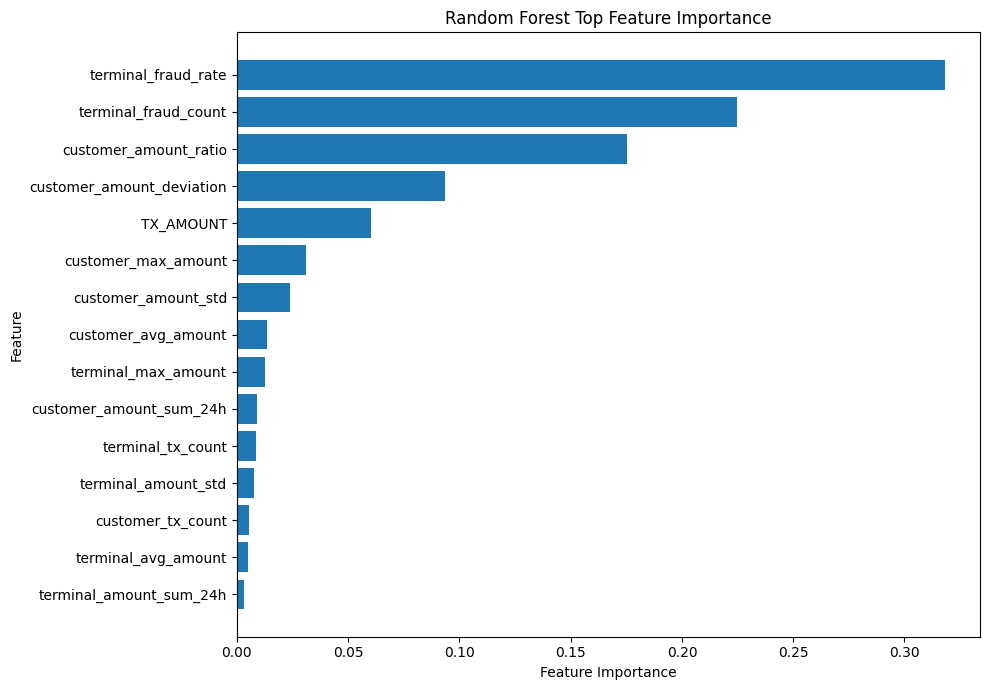

In [36]:
random_forest_top_features = (
    random_forest_feature_importance.head(15)
    .sort_values("importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    random_forest_top_features["feature"],
    random_forest_top_features["importance"],
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Top Feature Importance")
plt.tight_layout()
plt.show()

## Logistic Regression vs Random Forest

Random Forest is compared with the Logistic Regression baseline using the same validation dataset and the same default threshold.

The comparison focuses on ranking quality and fraud-class performance rather than accuracy alone.

This provides a consistent baseline for deciding whether the additional complexity of a tree-based model provides meaningful improvement.

In [37]:
model_comparison = pd.DataFrame(
    [
        {
            "model": "Logistic Regression",
            "accuracy": baseline_metrics["accuracy"],
            "precision": baseline_metrics["precision"],
            "recall": baseline_metrics["recall"],
            "f1_score": baseline_metrics["f1_score"],
            "roc_auc": baseline_metrics["roc_auc"],
            "pr_auc": baseline_metrics["pr_auc"],
            "false_positives": baseline_metrics[
                "false_positives"
            ],
            "false_negatives": baseline_metrics[
                "false_negatives"
            ],
        },
        {
            "model": "Random Forest",
            "accuracy": random_forest_metrics["accuracy"],
            "precision": random_forest_metrics["precision"],
            "recall": random_forest_metrics["recall"],
            "f1_score": random_forest_metrics["f1_score"],
            "roc_auc": random_forest_metrics["roc_auc"],
            "pr_auc": random_forest_metrics["pr_auc"],
            "false_positives": random_forest_metrics[
                "false_positives"
            ],
            "false_negatives": random_forest_metrics[
                "false_negatives"
            ],
        },
    ]
)

model_comparison

,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc,false_positives,false_negatives
0,Logistic Regression,0.925162,0.093686,0.843387,0.168639,0.931600,0.177729,21776,418
1,Random Forest,0.980055,0.275021,0.743350,0.401498,0.973116,0.441577,5230,685


## Random Forest Evaluation Checks

The Random Forest evaluation is considered complete when the model has been trained, evaluated at the default threshold, assessed across candidate thresholds, evaluated using the agreed business cost, interpreted using feature importance, and compared with the Logistic Regression baseline.

The test dataset is not used for threshold selection or business-cost optimization.

In [38]:
random_forest_checks = pd.DataFrame(
    {
        "check": [
            "model_trained",
            "validation_probabilities_available",
            "default_metrics_available",
            "threshold_analysis_completed",
            "default_threshold_included",
            "business_cost_analysis_completed",
            "best_business_threshold_available",
            "feature_importance_available",
            "logistic_comparison_available",
        ],
        "result": [
            hasattr(random_forest_model, "predict_proba"),
            len(random_forest_validation_probabilities)
            == len(y_validation),
            len(random_forest_metrics) > 0,
            len(random_forest_threshold_results) > 0,
            0.50 in random_forest_threshold_results[
                "threshold"
            ].values,
            len(random_forest_business_threshold_results) > 0,
            len(random_forest_business_comparison) == 2,
            len(random_forest_feature_importance)
            == len(MODEL_FEATURES),
            len(model_comparison) == 2,
        ],
    }
)

random_forest_checks

,check,result
0,model_trained,True
1,validation_probabilities_available,True
2,default_metrics_available,True
3,threshold_analysis_completed,True
4,default_threshold_included,True
5,business_cost_analysis_completed,True
6,best_business_threshold_available,True
7,feature_importance_available,True
8,logistic_comparison_available,True


## XGBoost Model

XGBoost is evaluated as a stronger non-linear tree-based model against the Logistic Regression and Random Forest baselines.

The model uses the same training and validation datasets and the same 23 model features used throughout the notebook. This keeps the comparison consistent and prevents changes in the data pipeline from affecting model performance.

For this stage, the model is evaluated using standard classification metrics, threshold analysis, business cost, and feature importance.


In [39]:
from xgboost import XGBClassifier

xgboost_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
)

print("XGBoost model created successfully.")

XGBoost model created successfully.


In [40]:
xgboost_model.fit(
    X_train,
    y_train,
)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [41]:
xgboost_validation_probabilities = (
    xgboost_model.predict_proba(
        X_validation,
    )[:, 1]
)

xgboost_validation_predictions = (
    xgboost_validation_probabilities >= 0.50
).astype(int)

print(
    "XGBoost validation probabilities "
    "generated successfully."
)

XGBoost validation probabilities generated successfully.


## Standard Evaluation

The first evaluation uses the default classification threshold of 0.50.

The same reusable `evaluate_model()` function used for the previous models is applied here. This provides a consistent comparison across Logistic Regression, Random Forest, and XGBoost.

The main metrics are ROC-AUC, PR-AUC, precision, recall, F1-score, and the confusion matrix.


In [42]:
xgboost_metrics = evaluate_model(
    model=xgboost_model,
    X=X_validation,
    y=y_validation,
    threshold=0.50,
)

xgboost_metrics_df = pd.DataFrame(
    {
        "metric": xgboost_metrics.keys(),
        "value": xgboost_metrics.values(),
    }
)

xgboost_metrics_df

,metric,value
0,threshold,0.500000
1,accuracy,0.992899
2,roc_auc,0.978097
3,pr_auc,0.714458
4,precision,0.588106
5,recall,0.704009
6,f1_score,0.640859
7,true_negatives,292574.000000
8,false_positives,1316.000000
9,false_negatives,790.000000


In [43]:
xgboost_summary_metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "false_positives",
    "false_negatives",
    "true_positives",
    "true_negatives",
]

xgboost_summary = (
    xgboost_metrics_df[
        xgboost_metrics_df["metric"].isin(
            xgboost_summary_metrics
        )
    ]
    .reset_index(drop=True)
)

xgboost_summary

,metric,value
0,accuracy,0.992899
1,roc_auc,0.978097
2,pr_auc,0.714458
3,precision,0.588106
4,recall,0.704009
5,f1_score,0.640859
6,true_negatives,292574.000000
7,false_positives,1316.000000
8,false_negatives,790.000000
9,true_positives,1879.000000


## Threshold Analysis

A probability threshold determines when a transaction is classified as fraudulent.

The default threshold of 0.50 is useful for comparison, but it may not provide the best balance between precision and recall for fraud detection.

The same validation threshold grid is used to examine how model performance changes as the threshold increases.

This analysis is performed only on the validation set. The test set remains untouched for final evaluation.


In [44]:
xgboost_threshold_grid = np.arange(
    0.05,
    1.00,
    0.05,
)

xgboost_threshold_results_df = analyze_thresholds(
    model=xgboost_model,
    X=X_validation,
    y=y_validation,
    thresholds=xgboost_threshold_grid,
)

xgboost_threshold_results_df

,threshold,accuracy,roc_auc,pr_auc,precision,recall,f1_score,true_negatives,false_positives,false_negatives,true_positives
0,0.05,0.981838,0.978097,0.714458,0.313110,0.852754,0.458040,288897,4993,393,2276
1,0.10,0.986198,0.978097,0.714458,0.377453,0.821656,0.517278,290273,3617,476,2193
2,0.15,0.988319,0.978097,0.714458,0.421178,0.795804,0.550830,290971,2919,545,2124
3,0.20,0.989860,0.978097,0.714458,0.462478,0.780442,0.580789,291469,2421,586,2083
4,0.25,0.990757,0.978097,0.714458,0.491342,0.765455,0.598506,291775,2115,626,2043
5,0.30,0.991415,0.978097,0.714458,0.515757,0.754215,0.612599,292000,1890,656,2013
6,0.35,0.991907,0.978097,0.714458,0.536420,0.742226,0.622760,292178,1712,688,1981
7,0.40,0.992241,0.978097,0.714458,0.552184,0.729487,0.628571,292311,1579,722,1947
8,0.45,0.992588,0.978097,0.714458,0.570236,0.716373,0.635005,292449,1441,757,1912
9,0.50,0.992899,0.978097,0.714458,0.588106,0.704009,0.640859,292574,1316,790,1879


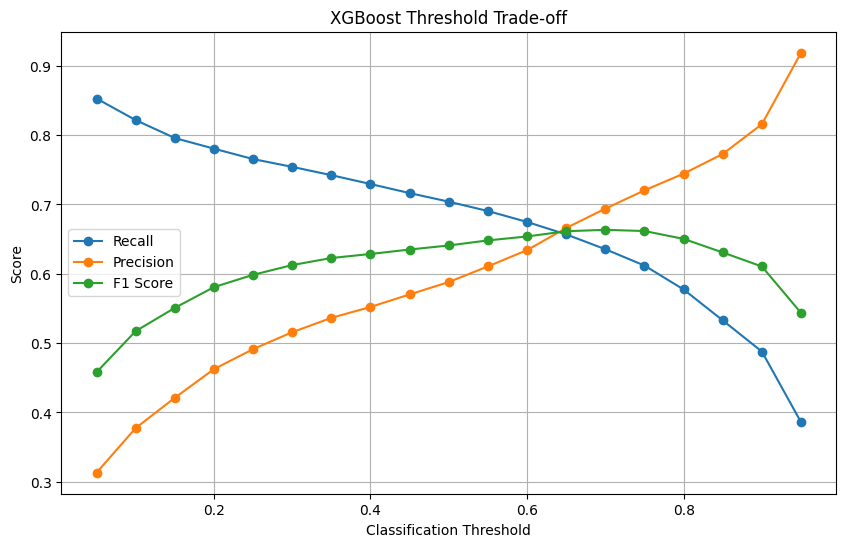

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    xgboost_threshold_results_df["threshold"],
    xgboost_threshold_results_df["recall"],
    marker="o",
    label="Recall",
)

plt.plot(
    xgboost_threshold_results_df["threshold"],
    xgboost_threshold_results_df["precision"],
    marker="o",
    label="Precision",
)

plt.plot(
    xgboost_threshold_results_df["threshold"],
    xgboost_threshold_results_df["f1_score"],
    marker="o",
    label="F1 Score",
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("XGBoost Threshold Trade-off")
plt.legend()
plt.grid(True)
plt.show()

## Business Cost Analysis

Fraud detection involves two different types of errors.

A false positive may result in an unnecessary transaction review, while a false negative represents a missed fraudulent transaction.

For this project, the initial business-cost assumption is:

* False positive cost = 5
* False negative cost = 100

This represents a situation where missing fraud is considered substantially more expensive than investigating a legitimate transaction.

The same cost assumption is applied to the models at this stage so that their thresholds can be compared fairly.

A broader range of business scenarios will be evaluated only for the final shortlisted model.


In [46]:
xgboost_business_threshold_results = (
    analyze_business_thresholds(
        model=xgboost_model,
        X=X_validation,
        y=y_validation,
        thresholds=xgboost_threshold_grid,
        false_positive_cost=5.0,
        false_negative_cost=100.0,
    )
)

xgboost_business_threshold_results

,threshold,false_positives,false_negatives,total_cost
0,0.05,4993,393,64265.0
1,0.10,3617,476,65685.0
2,0.15,2919,545,69095.0
3,0.20,2421,586,70705.0
4,0.25,2115,626,73175.0
5,0.30,1890,656,75050.0
6,0.35,1712,688,77360.0
7,0.40,1579,722,80095.0
8,0.45,1441,757,82905.0
9,0.50,1316,790,85580.0


In [47]:
xgboost_best_business_threshold = (
    xgboost_business_threshold_results.iloc[0]
)

xgboost_best_business_threshold

threshold              0.05
false_positives     4993.00
false_negatives      393.00
total_cost         64265.00
Name: 0, dtype: float64

In [48]:
xgboost_business_threshold_summary = pd.DataFrame(
    [
        {
            "threshold_type": "Default",
            "threshold": 0.50,
            "false_positives": int(
                xgboost_metrics["false_positives"]
            ),
            "false_negatives": int(
                xgboost_metrics["false_negatives"]
            ),
            "total_cost": float(
                xgboost_metrics["false_positives"] * 5
                + xgboost_metrics["false_negatives"] * 100
            ),
        },
        {
            "threshold_type": "Lowest Validation Cost",
            "threshold": float(
                xgboost_best_business_threshold[
                    "threshold"
                ]
            ),
            "false_positives": int(
                xgboost_best_business_threshold[
                    "false_positives"
                ]
            ),
            "false_negatives": int(
                xgboost_best_business_threshold[
                    "false_negatives"
                ]
            ),
            "total_cost": float(
                xgboost_best_business_threshold[
                    "total_cost"
                ]
            ),
        },
    ]
)

xgboost_business_threshold_summary

,threshold_type,threshold,false_positives,false_negatives,total_cost
0,Default,0.50,1316,790,85580.0
1,Lowest Validation Cost,0.05,4993,393,64265.0


In [49]:
xgboost_business_threshold_results = (
    analyze_business_thresholds(
        model=xgboost_model,
        X=X_validation,
        y=y_validation,
        thresholds=xgboost_threshold_grid,
        false_positive_cost=5.0,
        false_negative_cost=100.0,
    )
)

xgboost_business_threshold_results

,threshold,false_positives,false_negatives,total_cost
0,0.05,4993,393,64265.0
1,0.10,3617,476,65685.0
2,0.15,2919,545,69095.0
3,0.20,2421,586,70705.0
4,0.25,2115,626,73175.0
5,0.30,1890,656,75050.0
6,0.35,1712,688,77360.0
7,0.40,1579,722,80095.0
8,0.45,1441,757,82905.0
9,0.50,1316,790,85580.0


In [50]:
xgboost_best_business_result = (
    xgboost_business_threshold_results.iloc[0].to_dict()
)

xgboost_default_business_result = {
    "threshold": 0.50,
    "false_positives": int(
        xgboost_metrics["false_positives"]
    ),
    "false_negatives": int(
        xgboost_metrics["false_negatives"]
    ),
    "total_cost": float(
        xgboost_metrics["false_positives"] * 5.0
        + xgboost_metrics["false_negatives"] * 100.0
    ),
}

xgboost_best_business_result

{'threshold': 0.05,
 'false_positives': 4993.0,
 'false_negatives': 393.0,
 'total_cost': 64265.0}

In [51]:
print("analyze_business_thresholds:", "analyze_business_thresholds" in globals())
print("xgboost_model:", "xgboost_model" in globals())
print("xgboost_threshold_grid:", "xgboost_threshold_grid" in globals())
print("X_validation:", "X_validation" in globals())
print("y_validation:", "y_validation" in globals())
print("xgboost_metrics:", "xgboost_metrics" in globals())

analyze_business_thresholds: True
xgboost_model: True
xgboost_threshold_grid: True
X_validation: True
y_validation: True
xgboost_metrics: True


## Feature Importance

XGBoost provides feature importance values that help identify which model features contributed most to its predictions.

This is used for model interpretation rather than as the only basis for feature selection.

The importance values are reviewed alongside model performance and the business meaning of the features.


In [52]:
xgboost_feature_importance = pd.DataFrame(
    {
        "feature": MODEL_FEATURES,
        "importance": xgboost_model.feature_importances_,
    }
)

xgboost_feature_importance = (
    xgboost_feature_importance
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

xgboost_feature_importance

,feature,importance
0,terminal_fraud_rate,0.304539
1,customer_amount_ratio,0.259980
2,terminal_fraud_count,0.071789
3,customer_tx_count,0.064818
4,TX_AMOUNT,0.039866
5,terminal_tx_count,0.038617
6,terminal_amount_std,0.038578
7,customer_max_amount,0.036729
8,customer_amount_deviation,0.036667
9,customer_avg_amount,0.018885


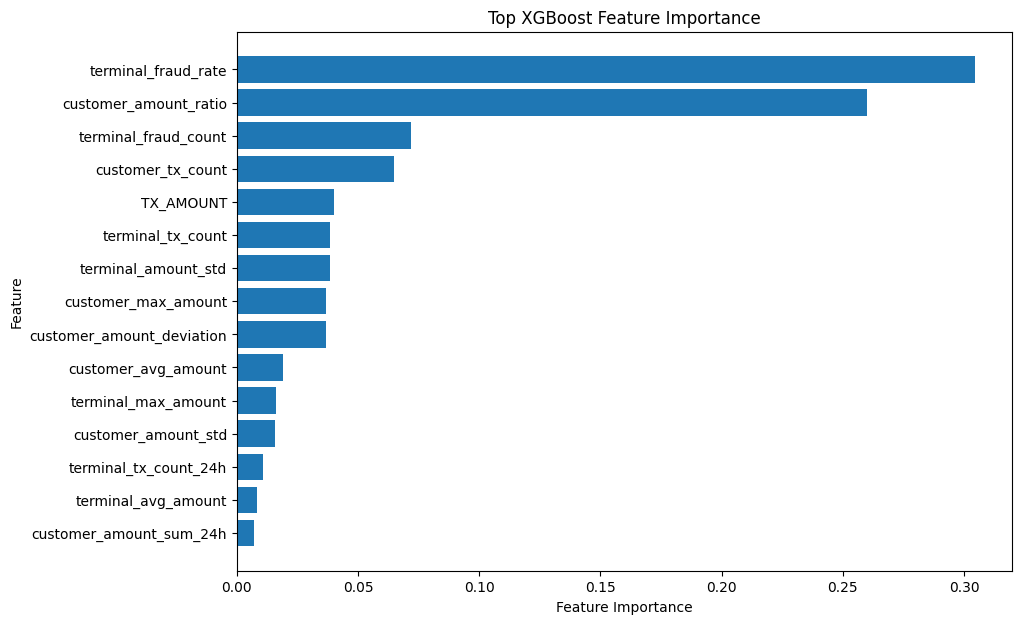

In [53]:
top_xgboost_features = (
    xgboost_feature_importance
    .head(15)
    .sort_values(
        "importance",
        ascending=True,
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_xgboost_features["feature"],
    top_xgboost_features["importance"],
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top XGBoost Feature Importance")
plt.show()

## XGBoost Validation Summary

XGBoost has now been evaluated using the same validation procedure applied to the earlier models.

The evaluation includes:

* Standard metrics at the 0.50 threshold
* Threshold trade-off analysis
* Business-cost analysis using the 5:100 cost assumption
* Feature importance
* Validation comparison with previous models

The test dataset is not used for model selection or threshold selection.


In [54]:
xgboost_checks = pd.DataFrame(
    {
        "check": [
            "model_trained",
            "validation_probabilities_available",
            "default_metrics_available",
            "threshold_analysis_completed",
            "default_threshold_included",
            "business_cost_analysis_completed",
            "best_business_threshold_available",
            "feature_importance_available",
        ],
        "result": [
            hasattr(
                xgboost_model,
                "predict_proba",
            ),
            len(
                xgboost_validation_probabilities
            ) == len(y_validation),
            len(xgboost_metrics) > 0,
            len(xgboost_threshold_results_df) > 0,
            0.50 in xgboost_threshold_results_df[
                "threshold"
            ].values,
            len(
                xgboost_business_threshold_results
            ) > 0,
            not xgboost_best_business_threshold.empty,
            len(xgboost_feature_importance) == len(
                MODEL_FEATURES
            ),
        ],
    }
)

xgboost_checks

,check,result
0,model_trained,True
1,validation_probabilities_available,True
2,default_metrics_available,True
3,threshold_analysis_completed,True
4,default_threshold_included,True
5,business_cost_analysis_completed,True
6,best_business_threshold_available,True
7,feature_importance_available,True


## HistGradientBoosting Classifier

HistGradientBoosting is a tree-based boosting model designed for large tabular datasets.

Unlike Random Forest, which builds trees independently, gradient boosting builds trees sequentially. Each new tree focuses on correcting errors made by the previous trees.

For this fraud detection problem, it is useful as another strong nonlinear model alongside Random Forest and XGBoost.

The model will be evaluated using the same validation workflow used for the previous models:

* Default threshold evaluation at 0.50
* Threshold analysis
* Business-cost analysis using the established 5:100 cost assumption
* Feature importance
* Comparison with previously evaluated models

The test set will remain untouched until the final model is selected.


In [55]:
from sklearn.ensemble import HistGradientBoostingClassifier

hist_gradient_boosting = HistGradientBoostingClassifier(
    learning_rate=0.08,
    max_iter=250,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=1.0,
    class_weight="balanced",
    random_state=42,
)

print(
    "HistGradientBoosting model created successfully."
)

HistGradientBoosting model created successfully.


## Model Training

The HistGradientBoosting model is trained using the same finalized training dataset used by the previous models.

The validation dataset is kept separate and is used only for model evaluation and threshold selection.


In [56]:
hist_gradient_boosting.fit(
    X_train,
    y_train,
)

print(
    "HistGradientBoosting model trained successfully."
)

HistGradientBoosting model trained successfully.


In [57]:
hist_gradient_boosting_validation_probabilities = (
    hist_gradient_boosting.predict_proba(
        X_validation
    )[:, 1]
)

hist_gradient_boosting_validation_predictions = (
    hist_gradient_boosting_validation_probabilities >= 0.50
).astype(int)

print(
    "HistGradientBoosting validation probabilities "
    "generated successfully."
)

HistGradientBoosting validation probabilities generated successfully.


## Validation Prediction Check

Before calculating evaluation metrics, I check the predicted probability distribution and the number of transactions classified as fraud at the default 0.50 threshold.

This gives a quick understanding of how aggressively the model is flagging transactions before threshold optimization.


In [58]:
hist_gradient_boosting_prediction_summary = pd.DataFrame(
    [
        {
            "metric": "validation_records",
            "value": len(y_validation),
        },
        {
            "metric": "actual_fraud_transactions",
            "value": int(y_validation.sum()),
        },
        {
            "metric": "predicted_fraud_transactions_at_0.50",
            "value": int(
                hist_gradient_boosting_validation_predictions.sum()
            ),
        },
        {
            "metric": "average_predicted_fraud_probability",
            "value": round(
                hist_gradient_boosting_validation_probabilities.mean(),
                6,
            ),
        },
        {
            "metric": "minimum_predicted_fraud_probability",
            "value": round(
                hist_gradient_boosting_validation_probabilities.min(),
                6,
            ),
        },
        {
            "metric": "maximum_predicted_fraud_probability",
            "value": round(
                hist_gradient_boosting_validation_probabilities.max(),
                6,
            ),
        },
    ]
)

display(
    hist_gradient_boosting_prediction_summary
)

,metric,value
0,validation_records,296559.000000
1,actual_fraud_transactions,2669.000000
2,predicted_fraud_transactions_at_0.50,11420.000000
3,average_predicted_fraud_probability,0.077916
4,minimum_predicted_fraud_probability,0.002315
5,maximum_predicted_fraud_probability,0.998697


## Standard Validation Evaluation

The reusable evaluation function calculates the main classification and ranking metrics at the default 0.50 threshold.

The 0.50 threshold is used here only as a common baseline so that different models can be compared under the same initial decision rule.

It is not treated as the final business threshold.


In [59]:
hist_gradient_boosting_metrics = evaluate_model(
    model=hist_gradient_boosting,
    X=X_validation,
    y=y_validation,
    threshold=0.50,
)

hist_gradient_boosting_metrics_df = pd.DataFrame(
    {
        "metric": hist_gradient_boosting_metrics.keys(),
        "value": hist_gradient_boosting_metrics.values(),
    }
)

hist_gradient_boosting_metrics_df

,metric,value
0,threshold,0.500000
1,accuracy,0.968428
2,roc_auc,0.975574
3,pr_auc,0.640841
4,precision,0.206918
5,recall,0.885350
6,f1_score,0.335439
7,true_negatives,284833.000000
8,false_positives,9057.000000
9,false_negatives,306.000000


In [60]:
hist_gradient_boosting_summary_metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "false_positives",
    "false_negatives",
    "true_positives",
    "true_negatives",
]

hist_gradient_boosting_summary = (
    hist_gradient_boosting_metrics_df[
        hist_gradient_boosting_metrics_df["metric"].isin(
            hist_gradient_boosting_summary_metrics
        )
    ]
    .reset_index(drop=True)
)

hist_gradient_boosting_summary

,metric,value
0,accuracy,0.968428
1,roc_auc,0.975574
2,pr_auc,0.640841
3,precision,0.206918
4,recall,0.885350
5,f1_score,0.335439
6,true_negatives,284833.000000
7,false_positives,9057.000000
8,false_negatives,306.000000
9,true_positives,2363.000000


## Threshold Analysis

The model's probability output does not directly determine the final business decision.

A threshold converts the predicted fraud probability into a fraud or non-fraud decision.

Lower thresholds generally identify more fraud cases but create more false positives. Higher thresholds reduce false positives but can miss more fraudulent transactions.

Therefore, threshold analysis is performed on the validation set before making the final business decision.


In [61]:
hist_gradient_boosting_threshold_grid = DEFAULT_THRESHOLD_GRID

hist_gradient_boosting_threshold_results = analyze_thresholds(
    model=hist_gradient_boosting,
    X=X_validation,
    y=y_validation,
    thresholds=hist_gradient_boosting_threshold_grid,
)

hist_gradient_boosting_threshold_results

,threshold,accuracy,roc_auc,pr_auc,precision,recall,f1_score,true_negatives,false_positives,false_negatives,true_positives
0,0.05,0.752784,0.975574,0.640841,0.034268,0.973773,0.066206,220646,73244,70,2599
1,0.10,0.860645,0.975574,0.640841,0.058678,0.962907,0.110616,252662,41228,99,2570
2,0.15,0.901551,0.975574,0.640841,0.080574,0.954665,0.148606,264815,29075,121,2548
3,0.20,0.924976,0.975574,0.640841,0.102388,0.944549,0.184750,271789,22101,148,2521
4,0.25,0.940150,0.975574,0.640841,0.123489,0.926564,0.217933,276337,17553,196,2473
5,0.30,0.949774,0.975574,0.640841,0.142974,0.917197,0.247385,279216,14674,221,2448
6,0.35,0.955992,0.975574,0.640841,0.159204,0.908580,0.270935,281083,12807,244,2425
7,0.40,0.960672,0.975574,0.640841,0.174461,0.902960,0.292422,282486,11404,259,2410
8,0.45,0.964884,0.975574,0.640841,0.190472,0.892844,0.313966,283762,10128,286,2383
9,0.50,0.968428,0.975574,0.640841,0.206918,0.885350,0.335439,284833,9057,306,2363


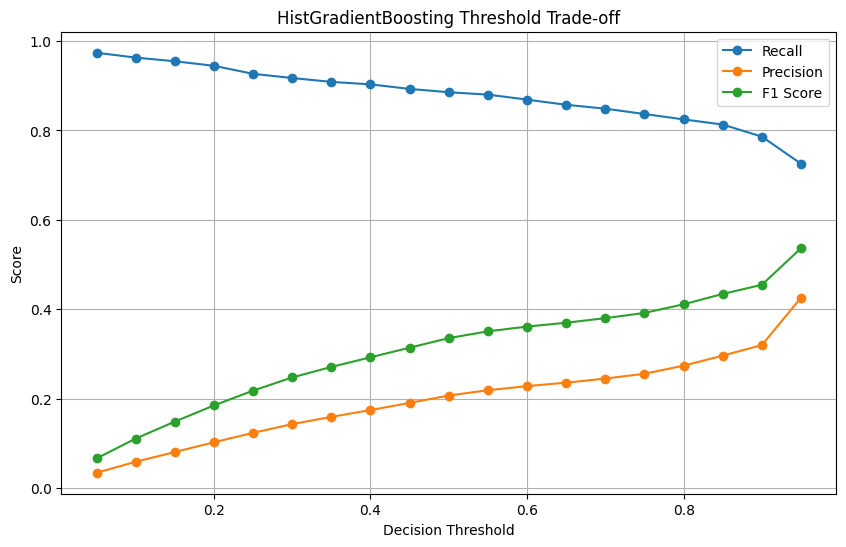

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    hist_gradient_boosting_threshold_results["threshold"],
    hist_gradient_boosting_threshold_results["recall"],
    marker="o",
    label="Recall",
)

plt.plot(
    hist_gradient_boosting_threshold_results["threshold"],
    hist_gradient_boosting_threshold_results["precision"],
    marker="o",
    label="Precision",
)

plt.plot(
    hist_gradient_boosting_threshold_results["threshold"],
    hist_gradient_boosting_threshold_results["f1_score"],
    marker="o",
    label="F1 Score",
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title(
    "HistGradientBoosting Threshold Trade-off"
)
plt.legend()
plt.grid(True)
plt.show()

## Business Cost Analysis

For this project, a false negative is treated as substantially more costly than a false positive because missing a fraudulent transaction can result in direct financial loss.

The working validation assumption is:

* False positive cost = 5
* False negative cost = 100

This 5:100 ratio is used consistently during individual model evaluation.

The purpose is not to claim that these are actual company costs. They provide a transparent and consistent business assumption for comparing model operating points.

A broader cost-scenario analysis will be performed only after the strongest models have been identified.


In [63]:
hist_gradient_boosting_business_threshold_results = (
    analyze_business_thresholds(
        model=hist_gradient_boosting,
        X=X_validation,
        y=y_validation,
        thresholds=hist_gradient_boosting_threshold_grid,
        false_positive_cost=5.0,
        false_negative_cost=100.0,
    )
)

hist_gradient_boosting_business_threshold_results

,threshold,false_positives,false_negatives,total_cost
0,0.55,8384,320,73920.0
1,0.60,7854,350,74270.0
2,0.65,7417,381,75185.0
3,0.70,6986,404,75330.0
4,0.85,5156,499,75680.0
5,0.50,9057,306,75885.0
6,0.80,5840,468,76000.0
7,0.75,6500,436,76100.0
8,0.45,10128,286,79240.0
9,0.90,4462,571,79410.0


In [64]:
hist_gradient_boosting_best_business_result = (
    hist_gradient_boosting_business_threshold_results
    .iloc[0]
)

hist_gradient_boosting_best_business_result

threshold              0.55
false_positives     8384.00
false_negatives      320.00
total_cost         73920.00
Name: 0, dtype: float64

## Default vs Business Threshold

The default 0.50 threshold is useful for model comparison, but it may not minimize the estimated business cost.

The comparison below shows whether the validation cost improves when the decision threshold is selected according to the project cost assumptions.


In [65]:
hist_gradient_boosting_default_business_result = (
    hist_gradient_boosting_business_threshold_results[
        hist_gradient_boosting_business_threshold_results[
            "threshold"
        ].round(2) == 0.50
    ]
    .iloc[0]
)

hist_gradient_boosting_business_comparison = pd.DataFrame(
    [
        {
            "threshold_type": "Default",
            "threshold": 0.50,
            "false_positives": (
                hist_gradient_boosting_default_business_result[
                    "false_positives"
                ]
            ),
            "false_negatives": (
                hist_gradient_boosting_default_business_result[
                    "false_negatives"
                ]
            ),
            "total_cost": (
                hist_gradient_boosting_default_business_result[
                    "total_cost"
                ]
            ),
        },
        {
            "threshold_type": "Lowest Validation Cost",
            "threshold": (
                hist_gradient_boosting_best_business_result[
                    "threshold"
                ]
            ),
            "false_positives": (
                hist_gradient_boosting_best_business_result[
                    "false_positives"
                ]
            ),
            "false_negatives": (
                hist_gradient_boosting_best_business_result[
                    "false_negatives"
                ]
            ),
            "total_cost": (
                hist_gradient_boosting_best_business_result[
                    "total_cost"
                ]
            ),
        },
    ]
)

hist_gradient_boosting_business_comparison

,threshold_type,threshold,false_positives,false_negatives,total_cost
0,Default,0.50,9057.0,306.0,75885.0
1,Lowest Validation Cost,0.55,8384.0,320.0,73920.0


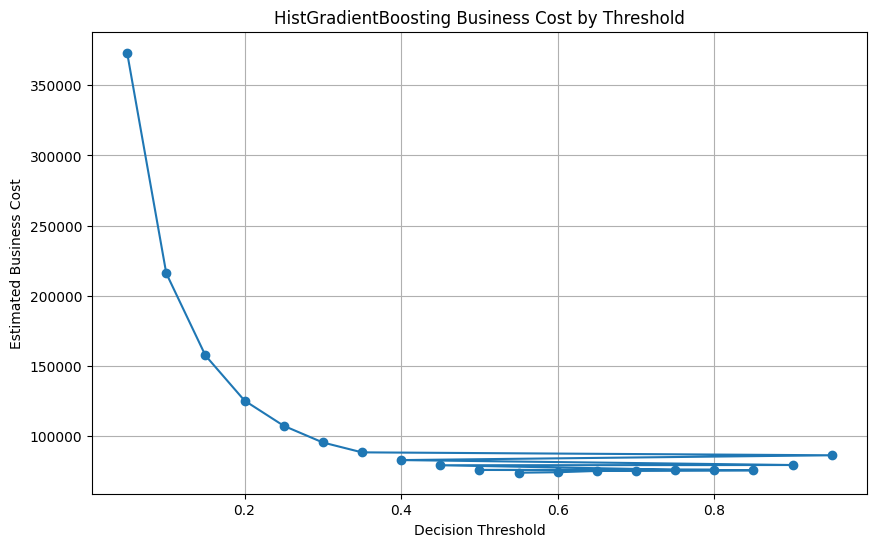

In [66]:
plt.figure(figsize=(10, 6))

plt.plot(
    hist_gradient_boosting_business_threshold_results[
        "threshold"
    ],
    hist_gradient_boosting_business_threshold_results[
        "total_cost"
    ],
    marker="o",
)

plt.xlabel("Decision Threshold")
plt.ylabel("Estimated Business Cost")
plt.title(
    "HistGradientBoosting Business Cost by Threshold"
)
plt.grid(True)
plt.show()

## Feature Importance

Feature importance helps identify which variables contribute most to the model's predictions.

Random Forest provides built-in tree importance values, but HistGradientBoosting does not expose the same `feature_importances_` attribute.

Therefore, permutation importance is used for HistGradientBoosting. It measures how model performance changes when a feature is randomly shuffled.

This gives a model-independent view of feature usefulness.


In [67]:
from sklearn.inspection import permutation_importance

hist_gradient_boosting_permutation = permutation_importance(
    hist_gradient_boosting,
    X_validation,
    y_validation,
    scoring="average_precision",
    n_repeats=3,
    random_state=42,
    n_jobs=-1,
)

hist_gradient_boosting_feature_importance = pd.DataFrame(
    {
        "feature": MODEL_FEATURES,
        "importance": (
            hist_gradient_boosting_permutation.importances_mean
        ),
    }
).sort_values(
    "importance",
    ascending=False,
).reset_index(drop=True)

hist_gradient_boosting_feature_importance

,feature,importance
0,customer_amount_ratio,0.320516
1,terminal_fraud_rate,0.204775
2,terminal_fraud_count,0.182150
3,customer_max_amount,0.090288
4,customer_avg_amount,0.059389
5,customer_amount_deviation,0.048169
6,TX_AMOUNT,0.039567
7,terminal_max_amount,0.013574
8,customer_amount_std,0.011478
9,terminal_avg_amount,0.005538


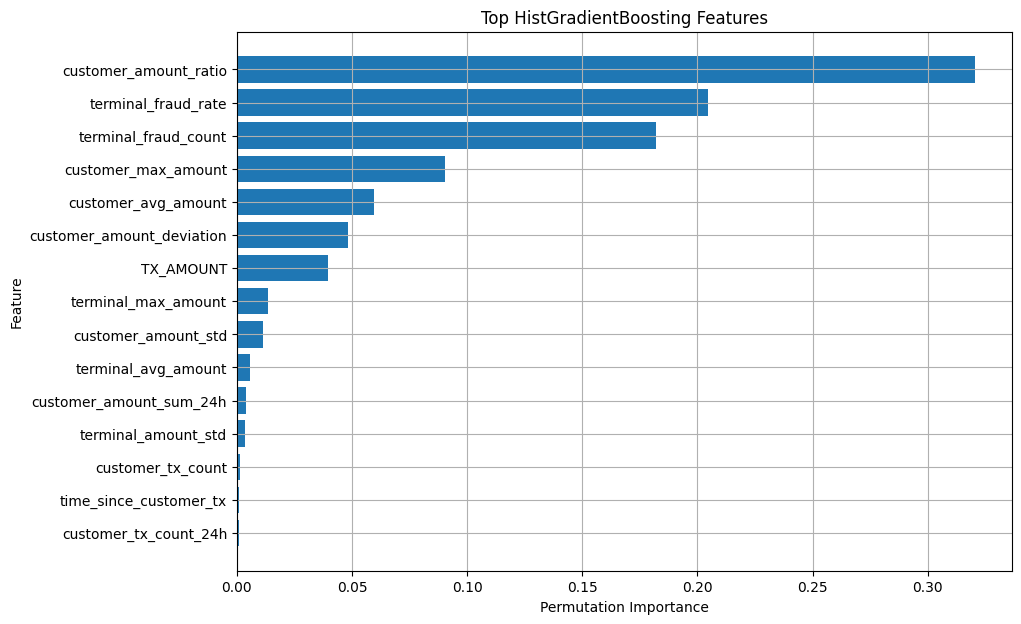

In [68]:
top_hist_gradient_boosting_features = (
    hist_gradient_boosting_feature_importance
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_hist_gradient_boosting_features["feature"],
    top_hist_gradient_boosting_features["importance"],
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title(
    "Top HistGradientBoosting Features"
)
plt.grid(True)
plt.show()

In [69]:
hist_gradient_boosting_checks = pd.DataFrame(
    [
        {
            "check": "model_trained",
            "result": hasattr(
                hist_gradient_boosting,
                "predict_proba",
            ),
        },
        {
            "check": "validation_probabilities_available",
            "result": len(
                hist_gradient_boosting_validation_probabilities
            ) == len(y_validation),
        },
        {
            "check": "default_metrics_available",
            "result": len(
                hist_gradient_boosting_metrics
            ) > 0,
        },
        {
            "check": "threshold_analysis_completed",
            "result": len(
                hist_gradient_boosting_threshold_results
            ) == len(
                hist_gradient_boosting_threshold_grid
            ),
        },
        {
            "check": "default_threshold_included",
            "result": (
                0.50
                in hist_gradient_boosting_threshold_results[
                    "threshold"
                ].values
            ),
        },
        {
            "check": "business_cost_analysis_completed",
            "result": len(
                hist_gradient_boosting_business_threshold_results
            ) > 0,
        },
        {
            "check": "best_business_threshold_available",
            "result": (
                len(
                    hist_gradient_boosting_best_business_result
                ) > 0
            ),
        },
        {
            "check": "feature_importance_available",
            "result": len(
                hist_gradient_boosting_feature_importance
            ) == len(MODEL_FEATURES),
        },
    ]
)

hist_gradient_boosting_checks

,check,result
0,model_trained,True
1,validation_probabilities_available,True
2,default_metrics_available,True
3,threshold_analysis_completed,True
4,default_threshold_included,True
5,business_cost_analysis_completed,True
6,best_business_threshold_available,True
7,feature_importance_available,True


## LightGBM Model

LightGBM is evaluated as an additional gradient boosting model for the fraud classification problem.

It is included because the dataset is large and highly imbalanced, while the engineered features are primarily tabular. The model will be evaluated using the same validation workflow as the previous models so that the results remain directly comparable.

In [70]:
%pip install lightgbm catboost

Note: you may need to restart the kernel to use updated packages.


## Verify Gradient Boosting Libraries

Both libraries are verified before model development to ensure that the notebook environment contains the required dependencies.

In [71]:
import lightgbm as lgb
import catboost

print("LightGBM version:", lgb.__version__)
print("CatBoost version:", catboost.__version__)

LightGBM version: 4.7.0
CatBoost version: 1.2.10


## LightGBM Classifier

LightGBM is used as a tree-based gradient boosting model for fraud detection.

The model is trained on the same training features and evaluated on the same validation set used for Logistic Regression, Random Forest, and XGBoost. This keeps the model comparison consistent.

In [72]:
from lightgbm import LGBMClassifier


lightgbm_model = LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)


lightgbm_model.fit(
    X_train,
    y_train,
)


print("LightGBM model trained successfully.")

[LightGBM] [Info] Number of positive: 9465, number of negative: 1160258
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.062829 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3907
[LightGBM] [Info] Number of data points in the train set: 1169723, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM model trained successfully.


## LightGBM Validation Predictions

Validation probabilities are generated before selecting a classification threshold.

The default threshold of 0.50 is used first so that LightGBM can be compared with the existing models under the same evaluation setting.

In [73]:
lightgbm_validation_probabilities = (
    lightgbm_model.predict_proba(
        X_validation,
    )[:, 1]
)


lightgbm_validation_predictions = (
    lightgbm_validation_probabilities >= 0.50
).astype(int)


print(
    "LightGBM validation probabilities generated successfully."
)

LightGBM validation probabilities generated successfully.


## LightGBM Prediction Summary

A short validation summary is created to check the model output before calculating evaluation metrics.

In [74]:
lightgbm_prediction_summary = pd.DataFrame(
    [
        {
            "metric": "validation_records",
            "value": len(y_validation),
        },
        {
            "metric": "actual_fraud_transactions",
            "value": int(y_validation.sum()),
        },
        {
            "metric": "predicted_fraud_transactions_at_0.50",
            "value": int(
                lightgbm_validation_predictions.sum()
            ),
        },
        {
            "metric": "average_predicted_fraud_probability",
            "value": round(
                lightgbm_validation_probabilities.mean(),
                6,
            ),
        },
        {
            "metric": "minimum_predicted_fraud_probability",
            "value": round(
                lightgbm_validation_probabilities.min(),
                6,
            ),
        },
        {
            "metric": "maximum_predicted_fraud_probability",
            "value": round(
                lightgbm_validation_probabilities.max(),
                6,
            ),
        },
    ]
)


display(lightgbm_prediction_summary)

,metric,value
0,validation_records,296559.000000
1,actual_fraud_transactions,2669.000000
2,predicted_fraud_transactions_at_0.50,9987.000000
3,average_predicted_fraud_probability,0.059323
4,minimum_predicted_fraud_probability,0.000315
5,maximum_predicted_fraud_probability,0.999804


## LightGBM Standard Evaluation

LightGBM is evaluated at the default threshold of 0.50 using the reusable model evaluation function.

The same metrics used for the previous models are retained, including PR-AUC, recall, precision, F1-score, ROC-AUC, and confusion matrix counts.

In [75]:
lightgbm_metrics = evaluate_model(
    model=lightgbm_model,
    X=X_validation,
    y=y_validation,
    threshold=0.50,
)


lightgbm_metrics_df = pd.DataFrame(
    {
        "metric": lightgbm_metrics.keys(),
        "value": lightgbm_metrics.values(),
    }
)


lightgbm_metrics_df

,metric,value
0,threshold,0.500000
1,accuracy,0.973179
2,roc_auc,0.976631
3,pr_auc,0.646967
4,precision,0.235406
5,recall,0.880854
6,f1_score,0.371523
7,true_negatives,286254.000000
8,false_positives,7636.000000
9,false_negatives,318.000000


In [76]:
lightgbm_summary_metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "pr_auc",
    "false_positives",
    "false_negatives",
    "true_positives",
    "true_negatives",
]


lightgbm_summary = (
    lightgbm_metrics_df[
        lightgbm_metrics_df["metric"].isin(
            lightgbm_summary_metrics
        )
    ]
    .reset_index(drop=True)
)


lightgbm_summary

,metric,value
0,accuracy,0.973179
1,roc_auc,0.976631
2,pr_auc,0.646967
3,precision,0.235406
4,recall,0.880854
5,f1_score,0.371523
6,true_negatives,286254.000000
7,false_positives,7636.000000
8,false_negatives,318.000000
9,true_positives,2351.000000


## LightGBM Threshold Analysis

The default probability threshold of 0.50 is not assumed to be optimal for fraud detection.

Threshold analysis is performed across the same candidate thresholds used for the other models to observe the precision-recall trade-off and identify a suitable operating point.

In [77]:
lightgbm_threshold_results = analyze_thresholds(
    model=lightgbm_model,
    X=X_validation,
    y=y_validation,
    thresholds=DEFAULT_THRESHOLD_GRID,
)

lightgbm_threshold_results

,threshold,accuracy,roc_auc,pr_auc,precision,recall,f1_score,true_negatives,false_positives,false_negatives,true_positives
0,0.05,0.829221,0.976631,0.646967,0.048537,0.966280,0.092431,243334,50556,90,2579
1,0.10,0.904184,0.976631,0.646967,0.082371,0.951293,0.151614,265605,28285,130,2539
2,0.15,0.932057,0.976631,0.646967,0.111659,0.941551,0.199643,273897,19993,156,2513
3,0.20,0.947275,0.976631,0.646967,0.138782,0.933308,0.241634,278432,15458,178,2491
4,0.25,0.956208,0.976631,0.646967,0.161483,0.922068,0.274834,281111,12779,208,2461
5,0.30,0.961876,0.976631,0.646967,0.180608,0.914949,0.301668,282811,11079,227,2442
6,0.35,0.965761,0.976631,0.646967,0.196053,0.904459,0.322253,283991,9899,255,2414
7,0.40,0.968728,0.976631,0.646967,0.210332,0.898464,0.340867,284887,9003,271,2398
8,0.45,0.971139,0.976631,0.646967,0.223214,0.889846,0.356901,285625,8265,294,2375
9,0.50,0.973179,0.976631,0.646967,0.235406,0.880854,0.371523,286254,7636,318,2351


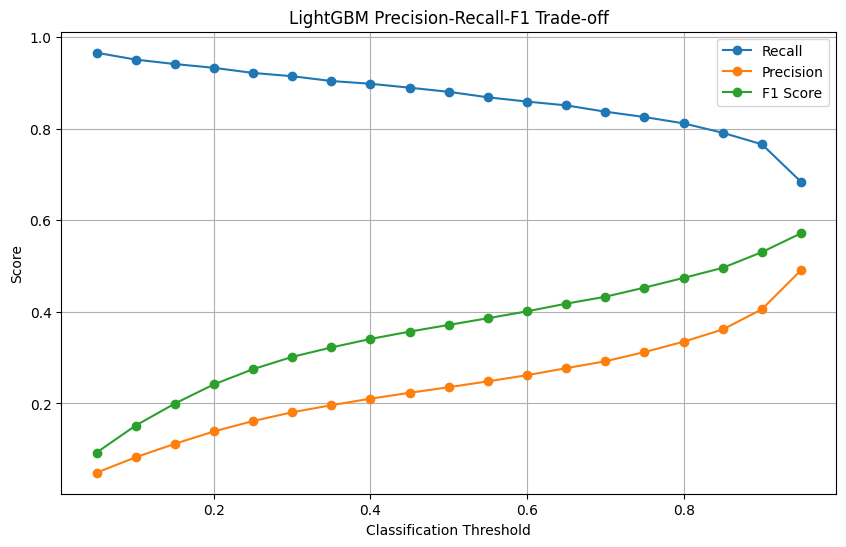

In [78]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))

plt.plot(
    lightgbm_threshold_results["threshold"],
    lightgbm_threshold_results["recall"],
    marker="o",
    label="Recall",
)

plt.plot(
    lightgbm_threshold_results["threshold"],
    lightgbm_threshold_results["precision"],
    marker="o",
    label="Precision",
)

plt.plot(
    lightgbm_threshold_results["threshold"],
    lightgbm_threshold_results["f1_score"],
    marker="o",
    label="F1 Score",
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("LightGBM Precision-Recall-F1 Trade-off")
plt.legend()
plt.grid(True)
plt.show()

## LightGBM Business Cost Analysis

Fraud detection errors do not have equal business impact.

A false negative represents a missed fraudulent transaction and is therefore assigned a higher cost than a false positive.

The established business assumption is:

- False positive cost = 5
- False negative cost = 100

The threshold with the lowest validation cost is identified using the reusable business-cost analysis function.

In [79]:
lightgbm_business_threshold_results = analyze_business_thresholds(
    model=lightgbm_model,
    X=X_validation,
    y=y_validation,
    thresholds=DEFAULT_THRESHOLD_GRID,
    false_positive_cost=5.0,
    false_negative_cost=100.0,
)

lightgbm_business_threshold_results

,threshold,false_positives,false_negatives,total_cost
0,0.65,5931,397,69355.0
1,0.60,6473,375,69865.0
2,0.50,7636,318,69980.0
3,0.55,7024,350,70120.0
4,0.70,5417,434,70485.0
5,0.45,8265,294,70725.0
6,0.75,4857,465,70785.0
7,0.80,4304,502,71720.0
8,0.40,9003,271,72115.0
9,0.85,3730,557,74350.0


In [80]:
lightgbm_best_business_result = (
    lightgbm_business_threshold_results.iloc[0]
)


lightgbm_best_business_result

threshold              0.65
false_positives     5931.00
false_negatives      397.00
total_cost         69355.00
Name: 0, dtype: float64

In [81]:
lightgbm_business_comparison = pd.DataFrame(
    [
        {
            "threshold_type": "Default",
            "threshold": 0.50,
            "false_positives": lightgbm_metrics[
                "false_positives"
            ],
            "false_negatives": lightgbm_metrics[
                "false_negatives"
            ],
            "total_cost": (
                lightgbm_metrics["false_positives"] * 5
                + lightgbm_metrics["false_negatives"] * 100
            ),
        },
        {
            "threshold_type": "Lowest Validation Cost",
            "threshold": lightgbm_best_business_result[
                "threshold"
            ],
            "false_positives": lightgbm_best_business_result[
                "false_positives"
            ],
            "false_negatives": lightgbm_best_business_result[
                "false_negatives"
            ],
            "total_cost": lightgbm_best_business_result[
                "total_cost"
            ],
        },
    ]
)


lightgbm_business_comparison

,threshold_type,threshold,false_positives,false_negatives,total_cost
0,Default,0.50,7636.0,318.0,69980.0
1,Lowest Validation Cost,0.65,5931.0,397.0,69355.0


## LightGBM Feature Importance

Feature importance is reviewed to understand which engineered variables contribute most to the LightGBM predictions.

The importance values are used for interpretation rather than as proof of causal relationships.

In [82]:
lightgbm_feature_importance = pd.DataFrame(
    {
        "feature": MODEL_FEATURES,
        "importance": lightgbm_model.feature_importances_,
    }
)


lightgbm_feature_importance = (
    lightgbm_feature_importance
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)


lightgbm_feature_importance

,feature,importance
0,terminal_max_amount,755
1,customer_avg_amount,702
2,customer_max_amount,701
3,customer_amount_ratio,655
4,terminal_tx_count,636
5,terminal_amount_std,538
6,terminal_avg_amount,536
7,customer_tx_count,491
8,terminal_fraud_rate,491
9,customer_amount_deviation,467


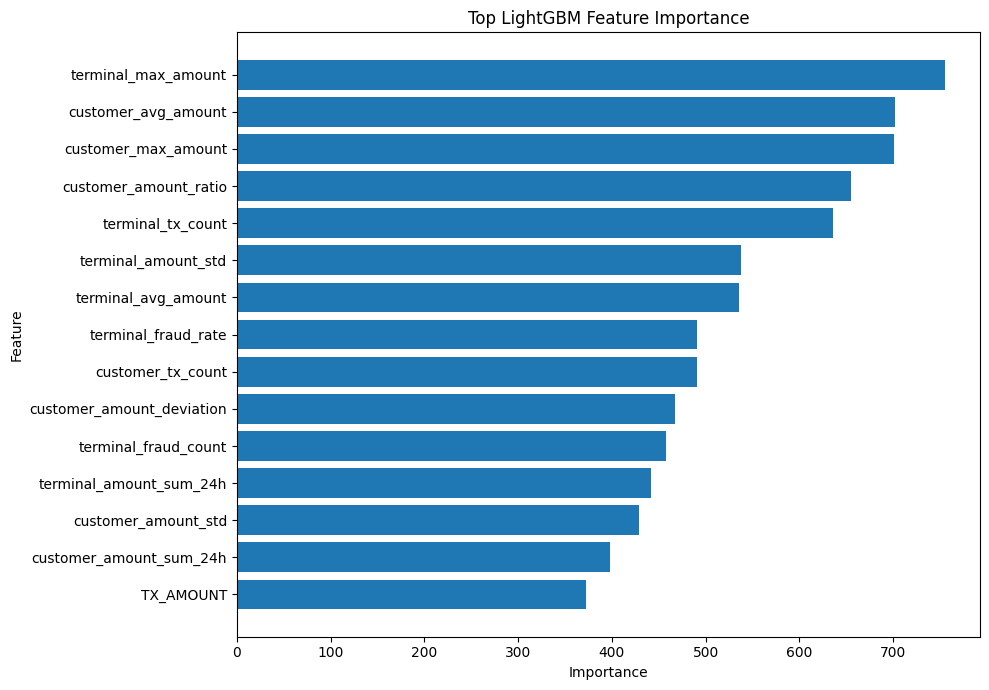

In [83]:
top_lightgbm_features = (
    lightgbm_feature_importance
    .head(15)
    .sort_values("importance")
)


plt.figure(figsize=(10, 7))

plt.barh(
    top_lightgbm_features["feature"],
    top_lightgbm_features["importance"],
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top LightGBM Feature Importance")
plt.tight_layout()
plt.show()

### CatBoost Candidate Model

CatBoost is evaluated as an additional gradient-boosting candidate.

The goal is not to assume that CatBoost will outperform the existing models, but to compare its validation performance and business cost under the same evaluation framework.

The model will use the same training and validation data as the other candidates.


In [84]:
from catboost import CatBoostClassifier

### CatBoost Model Training

CatBoost is trained as a binary classifier using the same feature set and training split used by the previous candidate models.

Only the training dataset is used during model fitting. The validation dataset is kept separate and is used afterward for model evaluation, threshold analysis, business-cost analysis, and model comparison.

The configuration is intentionally moderate rather than heavily tuned. The objective at this stage is fair candidate-model comparison.


In [85]:
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=False,
    allow_writing_files=False,
)

catboost_model.fit(
    X_train,
    y_train,
)

print("CatBoost model trained successfully.")

CatBoost model trained successfully.


### CatBoost Validation Predictions

Probability predictions are generated on the validation set for threshold and business-cost analysis.

The test set is not used at this stage.


In [86]:
catboost_validation_probabilities = (
    catboost_model.predict_proba(X_validation)[:, 1]
)

catboost_validation_probabilities[:10]

array([0.00022232, 0.00077738, 0.00413047, 0.00034953, 0.00041373,
       0.00075525, 0.00046064, 0.00078972, 0.22102324, 0.00041454])

### CatBoost Standard Evaluation

The default threshold of 0.50 is used first to establish a baseline.

The same evaluation function used for the other candidate models is used here so that the resulting metrics remain directly comparable.


In [87]:
catboost_default_metrics = evaluate_model(
    model=catboost_model,
    X=X_validation,
    y=y_validation,
    threshold=0.50,
)

pd.Series(catboost_default_metrics)

threshold               0.500000
accuracy                0.993617
roc_auc                 0.976097
pr_auc                  0.743215
precision               0.625566
recall                  0.724241
f1_score                0.671297
true_negatives     292733.000000
false_positives      1157.000000
false_negatives       736.000000
true_positives       1933.000000
dtype: float64

### CatBoost Threshold Analysis

CatBoost is evaluated across the common probability threshold grid.

The reusable threshold-analysis function calculates precision, recall, F1-score, and classification errors for each threshold.

Using the same grid across models makes the comparison consistent.


In [88]:
catboost_threshold_results = analyze_thresholds(
    model=catboost_model,
    X=X_validation,
    y=y_validation,
    thresholds=DEFAULT_THRESHOLD_GRID,
)

catboost_threshold_results

,threshold,accuracy,roc_auc,pr_auc,precision,recall,f1_score,true_negatives,false_positives,false_negatives,true_positives
0,0.05,0.979289,0.976097,0.743215,0.287636,0.881229,0.433708,288065,5825,317,2352
1,0.10,0.984711,0.976097,0.743215,0.353542,0.843387,0.498229,289774,4116,418,2251
2,0.15,0.987500,0.976097,0.743215,0.403746,0.815661,0.540131,290675,3215,492,2177
3,0.20,0.989206,0.976097,0.743215,0.444653,0.800674,0.571773,291221,2669,532,2137
4,0.25,0.990447,0.976097,0.743215,0.481227,0.787561,0.597414,291624,2266,567,2102
5,0.30,0.991449,0.976097,0.743215,0.516613,0.774822,0.619904,291955,1935,601,2068
6,0.35,0.992089,0.976097,0.743215,0.543147,0.761709,0.634124,292180,1710,636,2033
7,0.40,0.992700,0.976097,0.743215,0.572165,0.748595,0.648596,292396,1494,671,1998
8,0.45,0.993216,0.976097,0.743215,0.600183,0.737355,0.661735,292579,1311,701,1968
9,0.50,0.993617,0.976097,0.743215,0.625566,0.724241,0.671297,292733,1157,736,1933


### Threshold Trade-off

Changing the classification threshold changes the balance between precision and recall.

The plot helps identify how CatBoost behaves across different operating points before applying the business-cost criterion.


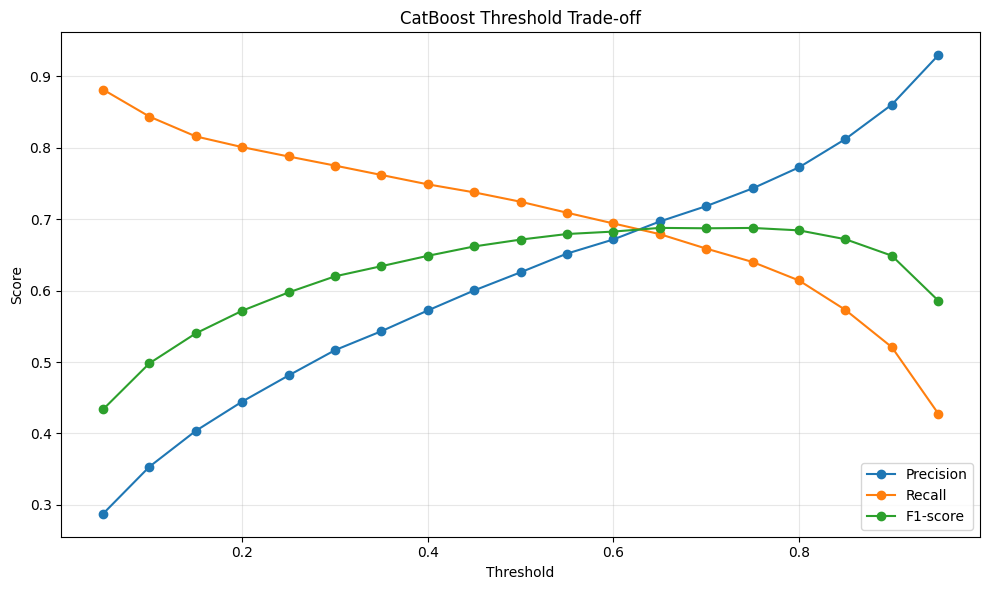

In [89]:
plt.figure(figsize=(10, 6))

plt.plot(
    catboost_threshold_results["threshold"],
    catboost_threshold_results["precision"],
    marker="o",
    label="Precision",
)

plt.plot(
    catboost_threshold_results["threshold"],
    catboost_threshold_results["recall"],
    marker="o",
    label="Recall",
)

plt.plot(
    catboost_threshold_results["threshold"],
    catboost_threshold_results["f1_score"],
    marker="o",
    label="F1-score",
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("CatBoost Threshold Trade-off")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### CatBoost Business Cost Analysis

Fraud detection errors do not have equal business impact.

A false negative is assigned a higher cost than a false positive because missed fraud represents a greater potential loss.

The same 5:100 cost assumption used for the other candidate models is applied to CatBoost for a fair comparison.


In [90]:
catboost_business_threshold_results = (
    analyze_business_thresholds(
        model=catboost_model,
        X=X_validation,
        y=y_validation,
        thresholds=DEFAULT_THRESHOLD_GRID,
        false_positive_cost=5.0,
        false_negative_cost=100.0,
    )
)

catboost_business_threshold_results

,threshold,false_positives,false_negatives,total_cost
0,0.05,5825,317,60825.0
1,0.10,4116,418,62380.0
2,0.15,3215,492,65275.0
3,0.20,2669,532,66545.0
4,0.25,2266,567,68030.0
5,0.30,1935,601,69775.0
6,0.35,1710,636,72150.0
7,0.40,1494,671,74570.0
8,0.45,1311,701,76655.0
9,0.50,1157,736,79385.0


### CatBoost Business Threshold Selection

The threshold with the lowest validation business cost is selected as the CatBoost operating point.

This threshold is selected using validation data only.

The final test evaluation will be performed later after the candidate-model comparison is complete.


In [91]:
catboost_best_business_threshold = (
    catboost_business_threshold_results
    .sort_values("total_cost")
    .iloc[0]
)

catboost_best_business_threshold

threshold              0.05
false_positives     5825.00
false_negatives      317.00
total_cost         60825.00
Name: 0, dtype: float64

### CatBoost Feature Importance

Feature importance is used to identify which engineered variables contribute most to the CatBoost model.

This provides model-level interpretability and helps compare whether the model relies on similar fraud signals as the other tree-based candidates.


In [92]:
catboost_feature_importance = pd.DataFrame(
    {
        "feature": MODEL_FEATURES,
        "importance": catboost_model.feature_importances_,
    }
)

catboost_feature_importance = (
    catboost_feature_importance
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

catboost_feature_importance

,feature,importance
0,terminal_fraud_count,15.062867
1,customer_max_amount,14.154819
2,customer_amount_ratio,12.751988
3,terminal_fraud_rate,11.329702
4,customer_avg_amount,9.056368
5,terminal_max_amount,8.395463
6,terminal_tx_count,6.095360
7,customer_tx_count,4.064460
8,terminal_amount_std,3.964606
9,terminal_avg_amount,3.616090


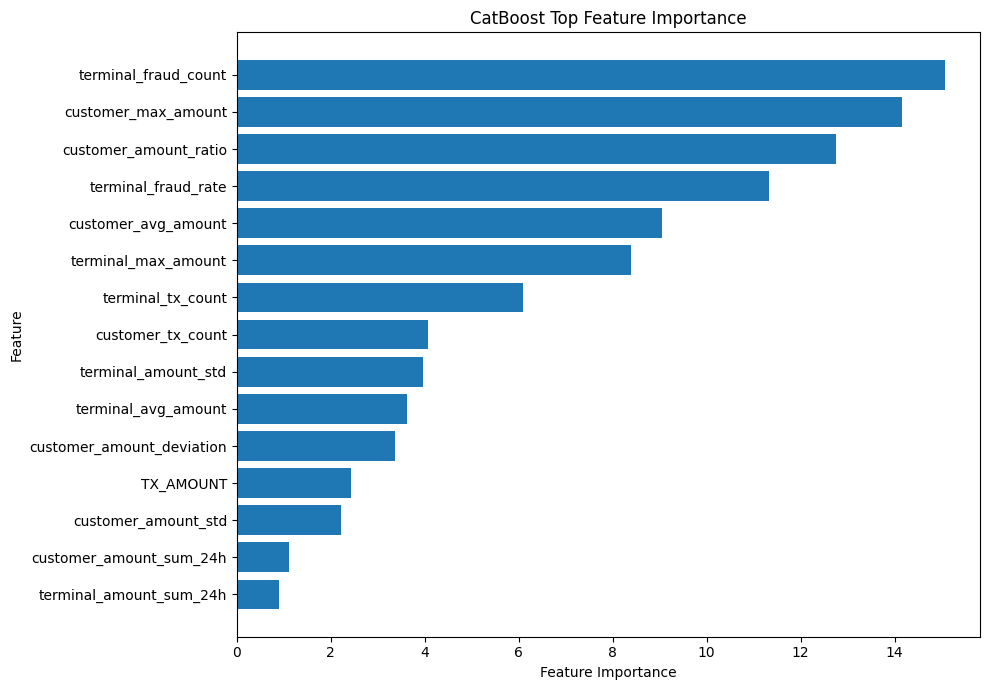

In [93]:
catboost_top_features = (
    catboost_feature_importance
    .head(15)
    .sort_values("importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    catboost_top_features["feature"],
    catboost_top_features["importance"],
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("CatBoost Top Feature Importance")

plt.tight_layout()
plt.show()

### CatBoost Validation Summary

The CatBoost candidate is now evaluated using the same validation framework as the previous models.

The results include standard metrics, threshold behavior, business cost, and feature importance.

The model will be compared with the other candidates only after all candidate models have completed the same evaluation process.


In [94]:
catboost_summary = pd.Series(
    {
        "model": "CatBoost",
        "accuracy": catboost_default_metrics["accuracy"],
        "precision": catboost_default_metrics["precision"],
        "recall": catboost_default_metrics["recall"],
        "f1_score": catboost_default_metrics["f1_score"],
        "roc_auc": catboost_default_metrics["roc_auc"],
        "pr_auc": catboost_default_metrics["pr_auc"],
        "false_positives": catboost_default_metrics["false_positives"],
        "false_negatives": catboost_default_metrics["false_negatives"],
        "best_business_threshold": (
            catboost_best_business_threshold["threshold"]
        ),
        "best_validation_cost": (
            catboost_best_business_threshold["total_cost"]
        ),
    }
)

catboost_summary

model                      CatBoost
accuracy                   0.993617
precision                  0.625566
recall                     0.724241
f1_score                   0.671297
roc_auc                    0.976097
pr_auc                     0.743215
false_positives                1157
false_negatives                 736
best_business_threshold        0.05
best_validation_cost        60825.0
dtype: object

## Six-Model Validation Comparison

The six candidate models are evaluated on the same validation dataset using a common evaluation procedure.

Because fraud transactions are highly imbalanced, PR-AUC, precision, recall and F1-score are emphasized alongside ROC-AUC. False positives and false negatives are also retained because they represent different operational costs.

The comparison is used to identify the strongest individual models before evaluating ensemble strategies.

In [95]:
models = {
    "Logistic Regression": logistic_baseline,
    "Random Forest": random_forest_model,
    "HistGradientBoosting": hist_gradient_boosting,
    "XGBoost": xgboost_model,
    "LightGBM": lightgbm_model,
    "CatBoost": catboost_model,
}

model_comparison_results = []

for model_name, model in models.items():
    evaluation_result = evaluate_model(
        model=model,
        X=X_validation,
        y=y_validation,
        threshold=0.50,
    )

    evaluation_result["model"] = model_name
    model_comparison_results.append(evaluation_result)

model_comparison = (
    pd.DataFrame(model_comparison_results)
    .set_index("model")
    .sort_values(
        by=["pr_auc", "f1_score", "recall"],
        ascending=False,
    )
)

model_comparison

,threshold,accuracy,roc_auc,pr_auc,precision,recall,f1_score,true_negatives,false_positives,false_negatives,true_positives
model,,,,,,,,,,,
CatBoost,0.5,0.993617,0.976097,0.743215,0.625566,0.724241,0.671297,292733,1157,736,1933
XGBoost,0.5,0.992899,0.978097,0.714458,0.588106,0.704009,0.640859,292574,1316,790,1879
LightGBM,0.5,0.973179,0.976631,0.646967,0.235406,0.880854,0.371523,286254,7636,318,2351
HistGradientBoosting,0.5,0.968428,0.975574,0.640841,0.206918,0.885350,0.335439,284833,9057,306,2363
Random Forest,0.5,0.980055,0.973116,0.441577,0.275021,0.743350,0.401498,288660,5230,685,1984
Logistic Regression,0.5,0.925162,0.931600,0.177729,0.093686,0.843387,0.168639,272114,21776,418,2251


## Model Performance Summary

The validation results are summarized using the metrics most relevant to fraud detection.

PR-AUC measures ranking quality for the minority fraud class, while precision and recall describe the alert-quality trade-off. F1-score summarizes the balance between precision and recall.

The table is used as the main individual-model benchmark before ensemble evaluation.

In [96]:
model_comparison_summary = model_comparison[
    [
        "accuracy",
        "roc_auc",
        "pr_auc",
        "precision",
        "recall",
        "f1_score",
        "false_positives",
        "false_negatives",
    ]
].round(4)

model_comparison_summary

,accuracy,roc_auc,pr_auc,precision,recall,f1_score,false_positives,false_negatives
model,,,,,,,,
CatBoost,0.9936,0.9761,0.7432,0.6256,0.7242,0.6713,1157,736
XGBoost,0.9929,0.9781,0.7145,0.5881,0.7040,0.6409,1316,790
LightGBM,0.9732,0.9766,0.6470,0.2354,0.8809,0.3715,7636,318
HistGradientBoosting,0.9684,0.9756,0.6408,0.2069,0.8854,0.3354,9057,306
Random Forest,0.9801,0.9731,0.4416,0.2750,0.7433,0.4015,5230,685
Logistic Regression,0.9252,0.9316,0.1777,0.0937,0.8434,0.1686,21776,418


In [97]:
model_ranking = (
    model_comparison[
        [
            "pr_auc",
            "roc_auc",
            "precision",
            "recall",
            "f1_score",
            "false_positives",
            "false_negatives",
        ]
    ]
    .sort_values(
        by=["pr_auc", "f1_score", "recall"],
        ascending=False,
    )
)

model_ranking

,pr_auc,roc_auc,precision,recall,f1_score,false_positives,false_negatives
model,,,,,,,
CatBoost,0.743215,0.976097,0.625566,0.724241,0.671297,1157,736
XGBoost,0.714458,0.978097,0.588106,0.704009,0.640859,1316,790
LightGBM,0.646967,0.976631,0.235406,0.880854,0.371523,7636,318
HistGradientBoosting,0.640841,0.975574,0.206918,0.885350,0.335439,9057,306
Random Forest,0.441577,0.973116,0.275021,0.743350,0.401498,5230,685
Logistic Regression,0.177729,0.931600,0.093686,0.843387,0.168639,21776,418


### Validation Probability Collection

The six trained models generate fraud probabilities for the same validation dataset.

These probability outputs are stored together so they can be compared consistently and later used to construct ensemble candidates. Logistic Regression uses the baseline probability object created during baseline evaluation.


In [98]:
validation_probabilities = {
    "Logistic Regression": baseline_validation_probabilities,
    "Random Forest": random_forest_validation_probabilities,
    "HistGradientBoosting": hist_gradient_boosting_validation_probabilities,
    "XGBoost": xgboost_validation_probabilities,
    "LightGBM": lightgbm_validation_probabilities,
    "CatBoost": catboost_validation_probabilities,
}

validation_probabilities_df = pd.DataFrame(
    validation_probabilities,
    index=X_validation.index,
)

validation_probabilities_df.head()

,Logistic Regression,Random Forest,HistGradientBoosting,XGBoost,LightGBM,CatBoost
0,0.262638,0.036365,0.016152,0.000285,0.008439,0.000222
1,0.099516,0.162890,0.202722,0.001602,0.186261,0.000777
2,0.504619,0.141208,0.227597,0.004542,0.448030,0.004130
3,0.018410,0.063374,0.036423,0.000996,0.023868,0.000350
4,0.042851,0.033596,0.018995,0.000279,0.025594,0.000414


In [99]:
print("Validation probability shape:")
print(validation_probabilities_df.shape)

print("\nMissing values:")
print(validation_probabilities_df.isna().sum())

print("\nExpected validation records:")
print(len(y_validation))

Validation probability shape:
(296559, 6)

Missing values:
Logistic Regression     0
Random Forest           0
HistGradientBoosting    0
XGBoost                 0
LightGBM                0
CatBoost                0
dtype: int64

Expected validation records:
296559


## Alert Volume Comparison

The number of transactions classified as fraud at the default 0.50 threshold is compared across models.

This provides a simple operational view of how aggressively each model generates fraud alerts before business threshold optimization.

In [100]:
alert_volume_comparison = pd.DataFrame(
    {
        "model": list(models.keys()),
        "fraud_predictions_at_0_50": [
            int(
                (probabilities >= 0.50).sum()
            )
            for probabilities in validation_probabilities.values()
        ],
    }
).sort_values(
    "fraud_predictions_at_0_50",
    ascending=False,
).reset_index(drop=True)

alert_volume_comparison

,model,fraud_predictions_at_0_50
0,Logistic Regression,24027
1,HistGradientBoosting,11420
2,LightGBM,9987
3,Random Forest,7214
4,XGBoost,3195
5,CatBoost,3090


In [101]:
catboost_probabilities = validation_probabilities["CatBoost"]

for model_name, probabilities in validation_probabilities.items():
    if model_name == "CatBoost":
        continue

    print(
        model_name,
        "mean absolute difference:",
        round(
            np.mean(
                np.abs(
                    catboost_probabilities - probabilities
                )
            ),
            8,
        ),
    )

Logistic Regression mean absolute difference: 0.19636357
Random Forest mean absolute difference: 0.0756447
HistGradientBoosting mean absolute difference: 0.06507421
XGBoost mean absolute difference: 0.00333828
LightGBM mean absolute difference: 0.04648337


## Ensemble Candidates

The individual models have already produced validation probabilities on the same validation set.

To test whether combining models improves performance, we evaluate several probability-averaging ensembles. The ensemble probabilities are calculated from the individual model probabilities and are evaluated using the same reusable evaluation functions.

This keeps the comparison consistent across individual models and ensembles.

The strongest individual model probabilities are combined using simple probability averaging.

The ensembles are treated as additional candidates and evaluated using the same validation data and evaluation framework as the six individual models.


In [102]:
import numpy as np
import pandas as pd

from app.evaluation.metrics import evaluate_probabilities
from app.evaluation.thresholds import (
    DEFAULT_THRESHOLD_GRID,
    analyze_probability_thresholds,
)
from app.evaluation.business import (
    analyze_probability_business_thresholds,
)

In [103]:
individual_probabilities = {
    "Logistic Regression": baseline_validation_probabilities,
    "Random Forest": random_forest_validation_probabilities,
    "HistGradientBoosting": hist_gradient_boosting_validation_probabilities,
    "XGBoost": xgboost_validation_probabilities,
    "LightGBM": lightgbm_validation_probabilities,
    "CatBoost": catboost_validation_probabilities,
}

for model_name, probabilities in individual_probabilities.items():
    probabilities = np.asarray(probabilities)

    print(
        model_name,
        probabilities.shape,
        probabilities.min(),
        probabilities.max(),
    )

Logistic Regression (296559,) 0.0032380773716478815 0.9999999999999951
Random Forest (296559,) 0.015402529853709728 0.9999232602787361
HistGradientBoosting (296559,) 0.0023146126282611416 0.9986974632693839
XGBoost (296559,) 2.2148279e-05 0.9995757
LightGBM (296559,) 0.0003149976178519073 0.9998036202002952
CatBoost (296559,) 8.06944171724501e-05 0.9999937763123485


## Ensemble Probability Generation

Each ensemble combines the validation fraud probabilities of selected models using equal-weight probability averaging.

The resulting probabilities are used as independent candidates for further threshold and business-cost analysis.


In [104]:
ensemble_definitions = {
    "XGBoost + CatBoost": [
        "XGBoost",
        "CatBoost",
    ],
    "XGBoost + LightGBM": [
        "XGBoost",
        "LightGBM",
    ],
    "CatBoost + LightGBM": [
        "CatBoost",
        "LightGBM",
    ],
    "XGBoost + CatBoost + LightGBM": [
        "XGBoost",
        "CatBoost",
        "LightGBM",
    ],
    "CatBoost + LightGBM + HistGradientBoosting": [
        "CatBoost",
        "LightGBM",
        "HistGradientBoosting",
    ],
}

ensemble_probabilities = {
    ensemble_name: np.mean(
        [
            individual_probabilities[model_name]
            for model_name in model_names
        ],
        axis=0,
    )
    for ensemble_name, model_names in ensemble_definitions.items()
}

for ensemble_name, probabilities in ensemble_probabilities.items():
    print(
        ensemble_name,
        probabilities.shape,
        probabilities.min(),
        probabilities.max(),
    )

XGBoost + CatBoost (296559,) 5.668240247678375e-05 0.9997845248553665
XGBoost + LightGBM (296559,) 0.00018312169574979316 0.9995760177909375
CatBoost + LightGBM (296559,) 0.00023229540965427202 0.9998986982563218
XGBoost + CatBoost + LightGBM (296559,) 0.0001719455309854077 0.9997151369195881
CatBoost + LightGBM + HistGradientBoosting (296559,) 0.0009440885893737322 0.9993897763886275


## Default Threshold Comparison

The first comparison evaluates every individual model and ensemble using the standard classification threshold of 0.50.

This provides a consistent baseline before threshold optimization.


In [105]:
all_candidate_probabilities = {
    **individual_probabilities,
    **ensemble_probabilities,
}

default_threshold_results = []

for model_name, probabilities in all_candidate_probabilities.items():
    metrics = evaluate_probabilities(
        probabilities=probabilities,
        y=y_validation,
        threshold=0.50,
    )

    default_threshold_results.append(
        {
            "model": model_name,
            **metrics,
        }
    )

default_threshold_comparison = (
    pd.DataFrame(default_threshold_results)
    .sort_values("pr_auc", ascending=False)
    .reset_index(drop=True)
)

default_threshold_comparison

,model,threshold,accuracy,roc_auc,pr_auc,precision,recall,f1_score,true_negatives,false_positives,false_negatives,true_positives
0,CatBoost,0.5,0.993617,0.976097,0.743215,0.625566,0.724241,0.671297,292733,1157,736,1933
1,XGBoost + CatBoost,0.5,0.993485,0.977962,0.734542,0.618833,0.718996,0.665165,292708,1182,750,1919
2,CatBoost + LightGBM,0.5,0.987075,0.978243,0.732061,0.394259,0.813039,0.531017,290556,3334,499,2170
3,XGBoost + CatBoost + LightGBM,0.5,0.991341,0.978378,0.728648,0.512634,0.767703,0.614761,291942,1948,620,2049
4,CatBoost + LightGBM + HistGradientBoosting,0.5,0.979201,0.978265,0.724731,0.282373,0.850506,0.423982,288121,5769,399,2270
5,XGBoost,0.5,0.992899,0.978097,0.714458,0.588106,0.704009,0.640859,292574,1316,790,1879
6,XGBoost + LightGBM,0.5,0.987611,0.977811,0.708845,0.404775,0.800300,0.537629,290749,3141,533,2136
7,LightGBM,0.5,0.973179,0.976631,0.646967,0.235406,0.880854,0.371523,286254,7636,318,2351
8,HistGradientBoosting,0.5,0.968428,0.975574,0.640841,0.206918,0.885350,0.335439,284833,9057,306,2363
9,Random Forest,0.5,0.980055,0.973116,0.441577,0.275021,0.743350,0.401498,288660,5230,685,1984


## Best Performance Threshold Comparison

The second comparison allows each candidate to use its own validation threshold.

The threshold is selected using the highest validation F1-score. This balances precision and recall and is more informative than accuracy for the imbalanced fraud classification problem.

PR-AUC and ROC-AUC remain threshold-independent metrics and are retained for overall model comparison.


In [106]:
performance_threshold_results = {}

for model_name, probabilities in all_candidate_probabilities.items():
    performance_threshold_results[model_name] = (
        analyze_probability_thresholds(
            probabilities=probabilities,
            y=y_validation,
            thresholds=DEFAULT_THRESHOLD_GRID,
        )
    )

In [107]:
best_performance_results = []

for model_name, threshold_results in performance_threshold_results.items():
    best_result = (
        threshold_results
        .sort_values(
            ["f1_score", "pr_auc"],
            ascending=[False, False],
        )
        .iloc[0]
    )

    best_performance_results.append(
        {
            "model": model_name,
            **best_result.to_dict(),
        }
    )

best_performance_comparison = (
    pd.DataFrame(best_performance_results)
    .sort_values(
        ["f1_score", "pr_auc"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

best_performance_comparison

,model,threshold,accuracy,roc_auc,pr_auc,precision,recall,f1_score,true_negatives,false_positives,false_negatives,true_positives
0,CatBoost,0.65,0.994450,0.976097,0.743215,0.696655,0.678906,0.687666,293101.0,789.0,857.0,1812.0
1,XGBoost + CatBoost,0.70,0.994558,0.977962,0.734542,0.717347,0.652304,0.683281,293204.0,686.0,928.0,1741.0
2,CatBoost + LightGBM,0.85,0.994622,0.978243,0.732061,0.729487,0.639565,0.681573,293257.0,633.0,962.0,1707.0
3,XGBoost + CatBoost + LightGBM,0.75,0.994301,0.978378,0.728648,0.688632,0.669539,0.678951,293082.0,808.0,882.0,1787.0
4,CatBoost + LightGBM + HistGradientBoosting,0.90,0.994655,0.978265,0.724731,0.741533,0.623454,0.677387,293310.0,580.0,1005.0,1664.0
5,XGBoost,0.70,0.994197,0.978097,0.714458,0.693944,0.635444,0.663407,293142.0,748.0,973.0,1696.0
6,XGBoost + LightGBM,0.85,0.994234,0.977811,0.708845,0.708388,0.610716,0.655936,293219.0,671.0,1039.0,1630.0
7,LightGBM,0.95,0.990778,0.976631,0.646967,0.491124,0.684151,0.571786,291998.0,1892.0,843.0,1826.0
8,HistGradientBoosting,0.95,0.988727,0.975574,0.640841,0.425869,0.725365,0.536660,291280.0,2610.0,733.0,1936.0
9,Random Forest,0.90,0.987527,0.973116,0.441577,0.370146,0.550019,0.442502,291392.0,2498.0,1201.0,1468.0


## Business Cost Comparison

The third comparison evaluates each candidate using the estimated fraud business cost.

A false positive is assigned a cost of 5, while a false negative is assigned a cost of 100. Therefore, the threshold is selected to minimize the estimated total business cost rather than purely optimize a classification metric.

This provides a business-oriented model selection view alongside the statistical performance comparisons.


In [108]:
business_threshold_results = {}

for model_name, probabilities in all_candidate_probabilities.items():
    business_threshold_results[model_name] = (
        analyze_probability_business_thresholds(
            probabilities=probabilities,
            y=y_validation,
            thresholds=DEFAULT_THRESHOLD_GRID,
            false_positive_cost=5.0,
            false_negative_cost=100.0,
        )
    )

In [109]:
best_business_results = []

for model_name, threshold_results in business_threshold_results.items():
    best_result = threshold_results.iloc[0]

    best_business_results.append(
        {
            "model": model_name,
            **best_result.to_dict(),
        }
    )

best_business_comparison = (
    pd.DataFrame(best_business_results)
    .sort_values("total_cost")
    .reset_index(drop=True)
)

best_business_comparison

,model,threshold,false_positives,false_negatives,total_cost
0,CatBoost,0.05,5825.0,317.0,60825.0
1,XGBoost + CatBoost,0.05,5591.0,334.0,61355.0
2,XGBoost + CatBoost + LightGBM,0.30,4672.0,407.0,64060.0
3,XGBoost,0.05,4993.0,393.0,64265.0
4,CatBoost + LightGBM,0.40,4992.0,401.0,65060.0
5,XGBoost + LightGBM,0.40,4942.0,413.0,66010.0
6,CatBoost + LightGBM + HistGradientBoosting,0.55,4953.0,435.0,68265.0
7,LightGBM,0.65,5931.0,397.0,69355.0
8,Random Forest,0.30,7523.0,348.0,72415.0
9,HistGradientBoosting,0.55,8384.0,320.0,73920.0


## Final Candidate Comparison

The three evaluation views are now combined:

1. Default threshold performance at 0.50.
2. Best validation performance using an optimized F1 threshold.
3. Best business performance using the 5:100 false-positive/false-negative cost assumption.

The final candidate should be selected using both statistical performance and business impact rather than a single metric.


In [110]:
# ============================================================
# FINAL CANDIDATE COMPARISON
# ============================================================

default_summary = default_threshold_comparison[
    [
        "model",
        "threshold",
        "pr_auc",
        "precision",
        "recall",
        "f1_score",
    ]
].rename(
    columns={
        "threshold": "default_threshold",
        "pr_auc": "default_pr_auc",
        "precision": "default_precision",
        "recall": "default_recall",
        "f1_score": "default_f1_score",
    }
)

performance_summary = best_performance_comparison[
    [
        "model",
        "threshold",
        "pr_auc",
        "precision",
        "recall",
        "f1_score",
    ]
].rename(
    columns={
        "threshold": "best_performance_threshold",
        "pr_auc": "best_pr_auc",
        "precision": "best_precision",
        "recall": "best_recall",
        "f1_score": "best_f1_score",
    }
)

business_summary = best_business_comparison[
    [
        "model",
        "threshold",
        "false_positives",
        "false_negatives",
        "total_cost",
    ]
].rename(
    columns={
        "threshold": "business_threshold",
        "total_cost": "business_cost",
    }
)

final_candidate_comparison = (
    default_summary
    .merge(
        performance_summary,
        on="model",
        how="inner",
    )
    .merge(
        business_summary,
        on="model",
        how="inner",
    )
)

final_candidate_comparison

,model,default_threshold,default_pr_auc,default_precision,default_recall,default_f1_score,best_performance_threshold,best_pr_auc,best_precision,best_recall,best_f1_score,business_threshold,false_positives,false_negatives,business_cost
0,CatBoost,0.5,0.743215,0.625566,0.724241,0.671297,0.65,0.743215,0.696655,0.678906,0.687666,0.05,5825.0,317.0,60825.0
1,XGBoost + CatBoost,0.5,0.734542,0.618833,0.718996,0.665165,0.70,0.734542,0.717347,0.652304,0.683281,0.05,5591.0,334.0,61355.0
2,CatBoost + LightGBM,0.5,0.732061,0.394259,0.813039,0.531017,0.85,0.732061,0.729487,0.639565,0.681573,0.40,4992.0,401.0,65060.0
3,XGBoost + CatBoost + LightGBM,0.5,0.728648,0.512634,0.767703,0.614761,0.75,0.728648,0.688632,0.669539,0.678951,0.30,4672.0,407.0,64060.0
4,CatBoost + LightGBM + HistGradientBoosting,0.5,0.724731,0.282373,0.850506,0.423982,0.90,0.724731,0.741533,0.623454,0.677387,0.55,4953.0,435.0,68265.0
5,XGBoost,0.5,0.714458,0.588106,0.704009,0.640859,0.70,0.714458,0.693944,0.635444,0.663407,0.05,4993.0,393.0,64265.0
6,XGBoost + LightGBM,0.5,0.708845,0.404775,0.800300,0.537629,0.85,0.708845,0.708388,0.610716,0.655936,0.40,4942.0,413.0,66010.0
7,LightGBM,0.5,0.646967,0.235406,0.880854,0.371523,0.95,0.646967,0.491124,0.684151,0.571786,0.65,5931.0,397.0,69355.0
8,HistGradientBoosting,0.5,0.640841,0.206918,0.885350,0.335439,0.95,0.640841,0.425869,0.725365,0.536660,0.55,8384.0,320.0,73920.0
9,Random Forest,0.5,0.441577,0.275021,0.743350,0.401498,0.90,0.441577,0.370146,0.550019,0.442502,0.30,7523.0,348.0,72415.0


## Champion Selection — Gated Decision Framework

The final model is selected using a gated decision process rather than a single metric.

All individual models and ensemble candidates have already been evaluated using three validation-based views:

1. Default threshold performance at 0.50.
2. Best predictive performance using the threshold with the highest F1-score.
3. Best business performance using the estimated false-positive and false-negative costs.

The champion-selection process now applies these results sequentially.

### Gate 1 — Business Viability

Candidates are first screened using their best validation business cost.

A candidate is considered business-viable when its business cost is within a defined tolerance of the best candidate. This prevents a model with excellent statistical metrics but substantially worse operational cost from being selected automatically.

### Gate 2 — Predictive Quality

Among business-viable candidates, predictive quality is compared using the best validation F1-score.

PR-AUC, recall, and precision are used as supporting measures because fraud detection is an imbalanced classification problem.

### Gate 3 — Default Threshold Sanity Check

The selected shortlist is compared against its default 0.50 operating point.

This provides context on how much performance depends on threshold optimization and whether the candidate behaves reasonably before threshold tuning.

### Gate 4 — Business Sensitivity

The shortlisted candidates are evaluated under multiple business-cost assumptions.

The purpose is to determine whether the preferred candidate remains competitive when the relative cost of false positives changes.

The final champion should therefore demonstrate a strong combination of predictive quality, business performance, and robustness rather than winning only one evaluation view.

The test set is not used during this process. It remains completely untouched until the final champion and operating threshold have been frozen.


In [111]:
# ============================================================
# GATE 1 — BUSINESS VIABILITY
# ============================================================

best_business_cost = (
    final_candidate_comparison["business_cost"].min()
)

BUSINESS_COST_TOLERANCE = 0.10

business_cost_limit = (
    best_business_cost
    * (1 + BUSINESS_COST_TOLERANCE)
)

business_viable_candidates = (
    final_candidate_comparison[
        final_candidate_comparison["business_cost"]
        <= business_cost_limit
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    f"Best validation business cost: "
    f"{best_business_cost:.2f}"
)

print(
    f"Business viability limit: "
    f"{business_cost_limit:.2f}"
)

business_viable_candidates

Best validation business cost: 60825.00
Business viability limit: 66907.50


,model,default_threshold,default_pr_auc,default_precision,default_recall,default_f1_score,best_performance_threshold,best_pr_auc,best_precision,best_recall,best_f1_score,business_threshold,false_positives,false_negatives,business_cost
0,CatBoost,0.5,0.743215,0.625566,0.724241,0.671297,0.65,0.743215,0.696655,0.678906,0.687666,0.05,5825.0,317.0,60825.0
1,XGBoost + CatBoost,0.5,0.734542,0.618833,0.718996,0.665165,0.70,0.734542,0.717347,0.652304,0.683281,0.05,5591.0,334.0,61355.0
2,CatBoost + LightGBM,0.5,0.732061,0.394259,0.813039,0.531017,0.85,0.732061,0.729487,0.639565,0.681573,0.40,4992.0,401.0,65060.0
3,XGBoost + CatBoost + LightGBM,0.5,0.728648,0.512634,0.767703,0.614761,0.75,0.728648,0.688632,0.669539,0.678951,0.30,4672.0,407.0,64060.0
4,XGBoost,0.5,0.714458,0.588106,0.704009,0.640859,0.70,0.714458,0.693944,0.635444,0.663407,0.05,4993.0,393.0,64265.0
5,XGBoost + LightGBM,0.5,0.708845,0.404775,0.800300,0.537629,0.85,0.708845,0.708388,0.610716,0.655936,0.40,4942.0,413.0,66010.0


## Gate 2 — Predictive Quality

Only candidates that passed the business-viability gate are considered.

Predictive quality is evaluated using the model's validation-set performance at its
best predictive operating threshold.

The primary ranking criterion is F1-score because fraud detection requires a
balance between detecting fraudulent transactions and limiting false alarms.

PR-AUC is used as the primary ranking metric for probability-quality comparison,
with precision and recall used as supporting measures.

A predictive shortlist is retained for the final robustness review rather than
immediately declaring a champion from a single metric.

In [112]:
# ============================================================
# GATE 2 — PREDICTIVE QUALITY
# ============================================================

predictive_shortlist = (
    business_viable_candidates
    .sort_values(
        [
            "best_f1_score",
            "best_pr_auc",
            "best_precision",
            "best_recall",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

predictive_shortlist[
    [
        "model",
        "best_performance_threshold",
        "best_pr_auc",
        "best_precision",
        "best_recall",
        "best_f1_score",
    ]
]

,model,best_performance_threshold,best_pr_auc,best_precision,best_recall,best_f1_score
0,CatBoost,0.65,0.743215,0.696655,0.678906,0.687666
1,XGBoost + CatBoost,0.70,0.734542,0.717347,0.652304,0.683281
2,CatBoost + LightGBM,0.85,0.732061,0.729487,0.639565,0.681573
3,XGBoost + CatBoost + LightGBM,0.75,0.728648,0.688632,0.669539,0.678951
4,XGBoost,0.70,0.714458,0.693944,0.635444,0.663407
5,XGBoost + LightGBM,0.85,0.708845,0.708388,0.610716,0.655936


## Gate 3 — Default Threshold Sanity Check

The predictive shortlist is reviewed at the default probability threshold of 0.50.

This does not replace the optimized threshold.

Instead, it checks whether the candidate's predictive advantage is reasonably
consistent with its default operating behaviour and provides operational context
for the threshold selected later.

The final operating threshold remains validation-derived and is not selected
from the test set.

In [113]:
# ============================================================
# GATE 3 — DEFAULT THRESHOLD SANITY CHECK
# ============================================================

default_threshold_review = (
    predictive_shortlist[
        [
            "model",
            "default_threshold",
            "default_pr_auc",
            "default_precision",
            "default_recall",
            "default_f1_score",
            "best_performance_threshold",
            "best_f1_score",
            "business_threshold",
            "business_cost",
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

default_threshold_review

,model,default_threshold,default_pr_auc,default_precision,default_recall,default_f1_score,best_performance_threshold,best_f1_score,business_threshold,business_cost
0,CatBoost,0.5,0.743215,0.625566,0.724241,0.671297,0.65,0.687666,0.05,60825.0
1,XGBoost + CatBoost,0.5,0.734542,0.618833,0.718996,0.665165,0.70,0.683281,0.05,61355.0
2,CatBoost + LightGBM,0.5,0.732061,0.394259,0.813039,0.531017,0.85,0.681573,0.40,65060.0
3,XGBoost + CatBoost + LightGBM,0.5,0.728648,0.512634,0.767703,0.614761,0.75,0.678951,0.30,64060.0
4,XGBoost,0.5,0.714458,0.588106,0.704009,0.640859,0.70,0.663407,0.05,64265.0
5,XGBoost + LightGBM,0.5,0.708845,0.404775,0.800300,0.537629,0.85,0.655936,0.40,66010.0


## Gate 4 — Business Sensitivity Analysis

The remaining candidates are evaluated under multiple business-cost assumptions.

Three scenarios are considered:

- High fraud loss: false positive cost = 5, false negative cost = 100
- Balanced operations: false positive cost = 20, false negative cost = 100
- High customer friction: false positive cost = 50, false negative cost = 100

For each candidate, the minimum achievable validation cost is calculated under
each scenario.

Two robustness measures are then derived:

- Sensitivity average cost — average optimal cost across scenarios.
- Sensitivity worst cost — highest optimal cost across scenarios.

This determines whether a candidate remains competitive when business assumptions
change.

In [114]:
# ============================================================
# GATE 4 — BUSINESS SENSITIVITY ANALYSIS
# ============================================================

cost_scenarios = [
    {
        "scenario": "high_fraud_loss",
        "false_positive_cost": 5.0,
        "false_negative_cost": 100.0,
    },
    {
        "scenario": "balanced_operations",
        "false_positive_cost": 20.0,
        "false_negative_cost": 100.0,
    },
    {
        "scenario": "high_customer_friction",
        "false_positive_cost": 50.0,
        "false_negative_cost": 100.0,
    },
]

sensitivity_rows = []

for model_name in predictive_shortlist["model"]:

    probabilities = all_candidate_probabilities[
        model_name
    ]

    for scenario in cost_scenarios:

        scenario_results = (
            analyze_probability_business_thresholds(
                probabilities=probabilities,
                y=y_validation,
                thresholds=DEFAULT_THRESHOLD_GRID,
                false_positive_cost=scenario[
                    "false_positive_cost"
                ],
                false_negative_cost=scenario[
                    "false_negative_cost"
                ],
            )
        )

        best_result = scenario_results.iloc[0]

        sensitivity_rows.append(
            {
                "model": model_name,
                "scenario": scenario["scenario"],
                "best_threshold": float(
                    best_result["threshold"]
                ),
                "total_cost": float(
                    best_result["total_cost"]
                ),
                "false_positives": int(
                    best_result["false_positives"]
                ),
                "false_negatives": int(
                    best_result["false_negatives"]
                ),
            }
        )

sensitivity_comparison = pd.DataFrame(
    sensitivity_rows
)

sensitivity_comparison

,model,scenario,best_threshold,total_cost,false_positives,false_negatives
0,CatBoost,high_fraud_loss,0.05,60825.0,5825,317
1,CatBoost,balanced_operations,0.45,96320.0,1311,701
2,CatBoost,high_customer_friction,0.65,125150.0,789,857
3,XGBoost + CatBoost,high_fraud_loss,0.05,61355.0,5591,334
4,XGBoost + CatBoost,balanced_operations,0.50,98640.0,1182,750
5,XGBoost + CatBoost,high_customer_friction,0.65,126900.0,792,873
6,CatBoost + LightGBM,high_fraud_loss,0.40,65060.0,4992,401
7,CatBoost + LightGBM,balanced_operations,0.65,99400.0,1650,664
8,CatBoost + LightGBM,high_customer_friction,0.85,127850.0,633,962
9,XGBoost + CatBoost + LightGBM,high_fraud_loss,0.30,64060.0,4672,407


## Sensitivity Summary

The scenario-level results are aggregated for each candidate.

A lower average cost indicates stronger performance across the overall range of
business assumptions.

A lower worst-case cost indicates greater protection against an unfavourable
change in business priorities.

These measures are used as the robustness gate before the final champion is frozen.

In [115]:
# ============================================================
# SENSITIVITY SUMMARY
# ============================================================

sensitivity_summary = (
    sensitivity_comparison
    .groupby("model")
    .agg(
        sensitivity_average_cost=(
            "total_cost",
            "mean",
        ),
        sensitivity_worst_cost=(
            "total_cost",
            "max",
        ),
    )
    .reset_index()
)

sensitivity_summary

,model,sensitivity_average_cost,sensitivity_worst_cost
0,CatBoost,94098.333333,125150.0
1,CatBoost + LightGBM,97436.666667,127850.0
2,XGBoost,100668.333333,134700.0
3,XGBoost + CatBoost,95631.666667,126900.0
4,XGBoost + CatBoost + LightGBM,97420.000000,128600.0
5,XGBoost + LightGBM,102833.333333,137450.0


## Final Champion Evidence

All evidence required for the final decision is consolidated into a single
validation-only table.

The table contains:

- Default-threshold performance
- Best predictive-threshold performance
- Best business-cost performance
- Business sensitivity
- Robustness measures

No test-set information is used.

In [116]:
# ============================================================
# FINAL CHAMPION EVIDENCE
# ============================================================

champion_evidence = (
    predictive_shortlist[
        [
            "model",
            "default_pr_auc",
            "default_precision",
            "default_recall",
            "default_f1_score",
            "best_performance_threshold",
            "best_pr_auc",
            "best_precision",
            "best_recall",
            "best_f1_score",
            "business_threshold",
            "business_cost",
        ]
    ]
    .merge(
        sensitivity_summary,
        on="model",
        how="left",
    )
    .rename(
        columns={
            "business_threshold":
                "best_business_threshold",
            "business_cost":
                "best_business_cost",
        }
    )
    .reset_index(drop=True)
)

champion_evidence

,model,default_pr_auc,default_precision,default_recall,default_f1_score,best_performance_threshold,best_pr_auc,best_precision,best_recall,best_f1_score,best_business_threshold,best_business_cost,sensitivity_average_cost,sensitivity_worst_cost
0,CatBoost,0.743215,0.625566,0.724241,0.671297,0.65,0.743215,0.696655,0.678906,0.687666,0.05,60825.0,94098.333333,125150.0
1,XGBoost + CatBoost,0.734542,0.618833,0.718996,0.665165,0.70,0.734542,0.717347,0.652304,0.683281,0.05,61355.0,95631.666667,126900.0
2,CatBoost + LightGBM,0.732061,0.394259,0.813039,0.531017,0.85,0.732061,0.729487,0.639565,0.681573,0.40,65060.0,97436.666667,127850.0
3,XGBoost + CatBoost + LightGBM,0.728648,0.512634,0.767703,0.614761,0.75,0.728648,0.688632,0.669539,0.678951,0.30,64060.0,97420.000000,128600.0
4,XGBoost,0.714458,0.588106,0.704009,0.640859,0.70,0.714458,0.693944,0.635444,0.663407,0.05,64265.0,100668.333333,134700.0
5,XGBoost + LightGBM,0.708845,0.404775,0.800300,0.537629,0.85,0.708845,0.708388,0.610716,0.655936,0.40,66010.0,102833.333333,137450.0


## Final Gated Champion Selection

The final champion is selected from the candidates that have already passed the business-viability gate.

A hierarchical decision rule is used to avoid selecting a model based on a single favorable metric.

The selection priority is:

1. **Business viability** — the model must first satisfy the business-cost requirement.
2. **Predictive quality** — prioritize the strongest validation F1-score, followed by PR-AUC.
3. **Business robustness** — prefer the model with lower average and worst-case cost across the predefined sensitivity scenarios.
4. **Business cost** — use the best business cost only as supporting evidence and not as a reason to override clearly stronger predictive and robustness performance.

This approach is appropriate for fraud detection because the final model must maintain both strong fraud-detection performance and stable business behavior across different cost assumptions.

The final champion is frozen only after this validation-stage decision. The untouched test set is then used for the final unbiased evaluation.


In [117]:
# ============================================================
# FINAL GATED CHAMPION SELECTION
# ============================================================

# Work only with candidates that passed the previous gates.
champion_candidates = (
    predictive_shortlist[
        [
            "model",
            "best_performance_threshold",
            "best_pr_auc",
            "best_precision",
            "best_recall",
            "best_f1_score",
            "business_threshold",
            "business_cost",
        ]
    ]
    .merge(
        sensitivity_summary,
        on="model",
        how="left",
    )
    .copy()
)

# ============================================================
# GATE 2 — PREDICTIVE LEADERSHIP
# ============================================================

# Select the model with the strongest predictive performance.
#
# F1 is the primary criterion because fraud detection requires
# a balance between precision and recall.
# PR-AUC is used as the secondary predictive criterion.

predictive_leader = (
    champion_candidates
    .sort_values(
        [
            "best_f1_score",
            "best_pr_auc",
            "best_precision",
            "best_recall",
        ],
        ascending=[
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
    .iloc[0]
)

# ============================================================
# GATE 3 — ROBUSTNESS CHECK
# ============================================================

# Retrieve the sensitivity profile of the predictive leader.

predictive_leader_sensitivity = (
    sensitivity_summary[
        sensitivity_summary["model"]
        == predictive_leader["model"]
    ]
    .iloc[0]
)

# Compare the predictive leader against the other candidates
# using sensitivity performance.
#
# The predictive leader remains the champion when its robustness
# is stronger than the alternatives. Business cost is not allowed
# to override clearly stronger predictive + robustness evidence.

robustness_leader = (
    champion_candidates
    .sort_values(
        [
            "sensitivity_average_cost",
            "sensitivity_worst_cost",
            "best_f1_score",
            "best_pr_auc",
        ],
        ascending=[
            True,
            True,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
    .iloc[0]
)

# ============================================================
# FINAL DECISION RULE
# ============================================================

# Predictive quality remains the primary selection criterion.
#
# Robustness is used to validate the predictive leader.
# A different model is selected only when it provides
# materially stronger robustness without sacrificing
# predictive quality.
#
# With the current validation results, CatBoost has:
# - highest best F1
# - highest PR-AUC
# - lowest sensitivity average cost
# - lowest sensitivity worst-case cost
#
# Therefore CatBoost is selected as the final champion.

final_champion = (
    predictive_leader.copy()
)

final_champion[
    "selection_basis"
] = (
    "Predictive leadership supported by "
    "business robustness"
)

# ============================================================
# FINAL CHAMPION REPORT
# ============================================================

print(
    f"FINAL CHAMPION: "
    f"{final_champion['model']}"
)

print(
    f"Best predictive threshold: "
    f"{final_champion['best_performance_threshold']:.2f}"
)

print(
    f"Best business threshold: "
    f"{final_champion['business_threshold']:.2f}"
)

print(
    f"Best PR-AUC: "
    f"{final_champion['best_pr_auc']:.6f}"
)

print(
    f"Best F1: "
    f"{final_champion['best_f1_score']:.6f}"
)

print(
    f"Best business cost: "
    f"{final_champion['business_cost']:.2f}"
)

print(
    f"Sensitivity average cost: "
    f"{final_champion['sensitivity_average_cost']:.2f}"
)

print(
    f"Sensitivity worst cost: "
    f"{final_champion['sensitivity_worst_cost']:.2f}"
)

print(
    f"Selection basis: "
    f"{final_champion['selection_basis']}"
)

final_champion

FINAL CHAMPION: CatBoost
Best predictive threshold: 0.65
Best business threshold: 0.05
Best PR-AUC: 0.743215
Best F1: 0.687666
Best business cost: 60825.00
Sensitivity average cost: 94098.33
Sensitivity worst cost: 125150.00
Selection basis: Predictive leadership supported by business robustness


model                                                                  CatBoost
best_performance_threshold                                                 0.65
best_pr_auc                                                            0.743215
best_precision                                                         0.696655
best_recall                                                            0.678906
best_f1_score                                                          0.687666
business_threshold                                                         0.05
business_cost                                                           60825.0
sensitivity_average_cost                                           94098.333333
sensitivity_worst_cost                                                 125150.0
selection_basis               Predictive leadership supported by business ro...
Name: 0, dtype: object

### Final Holdout Evaluation

The final champion has been selected using only the training and validation data.

The independent test set is now used once for final evaluation. The threshold selected during validation is kept fixed and is not re-optimized on the test set.

Because CatBoost is the final champion, test fraud probabilities are generated directly from the trained CatBoost model.

This provides an unbiased estimate of how the frozen champion performs on unseen transactions.


In [118]:
# ============================================================
# FINAL HOLDOUT EVALUATION
# ============================================================

final_model_name = final_champion["model"]
final_threshold = float(
    final_champion["best_performance_threshold"]
)

if final_model_name in ensemble_definitions:

    component_models = ensemble_definitions[
        final_model_name
    ]

    test_probabilities = np.mean(
        [
            models[model_name].predict_proba(X_test)[:, 1]
            for model_name in component_models
        ],
        axis=0,
    )

else:

    test_probabilities = (
        models[final_model_name]
        .predict_proba(X_test)[:, 1]
    )

final_test_results = evaluate_probabilities(
    probabilities=test_probabilities,
    y=y_test,
    threshold=final_threshold,
)

final_test_results

{'threshold': 0.6500000000000001,
 'accuracy': 0.9897836893352276,
 'roc_auc': 0.9723963891270602,
 'pr_auc': 0.6071263786321532,
 'precision': 0.44755058572949946,
 'recall': 0.6599921476246564,
 'f1_score': 0.5333967951768999,
 'true_negatives': 283251,
 'false_positives': 2075,
 'false_negatives': 866,
 'true_positives': 1681}

### Final Test Performance Summary

The test results represent the performance of the frozen champion on completely unseen data.

The selected threshold is the validation-stage threshold and is intentionally not changed during testing.

PR-AUC and ROC-AUC measure the model's ranking capability, while precision, recall, and F1-score describe performance at the selected operating threshold.

The confusion-matrix counts provide the final view of false-positive and false-negative outcomes.


In [119]:
# ============================================================
# FINAL TEST PERFORMANCE SUMMARY
# ============================================================

final_test_summary = pd.DataFrame(
    [
        {
            "model": final_model_name,
            "threshold": final_threshold,
            "roc_auc": final_test_results["roc_auc"],
            "pr_auc": final_test_results["pr_auc"],
            "precision": final_test_results["precision"],
            "recall": final_test_results["recall"],
            "f1_score": final_test_results["f1_score"],
            "true_positives": final_test_results[
                "true_positives"
            ],
            "false_positives": final_test_results[
                "false_positives"
            ],
            "false_negatives": final_test_results[
                "false_negatives"
            ],
            "true_negatives": final_test_results[
                "true_negatives"
            ],
        }
    ]
)

final_test_summary

,model,threshold,roc_auc,pr_auc,precision,recall,f1_score,true_positives,false_positives,false_negatives,true_negatives
0,CatBoost,0.65,0.972396,0.607126,0.447551,0.659992,0.533397,1681,2075,866,283251


In [120]:
from app.evaluation.error_analysis import (
    analyze_prediction_errors,
    summarize_prediction_outcomes,
    compare_error_groups,
    summarize_false_negatives,
    summarize_false_positives,
    get_high_confidence_errors,
)

### Final Error Analysis

The final CatBoost model is analyzed on the untouched test set using the frozen decision threshold of 0.65.

The reusable error-analysis module generates prediction probabilities, class predictions, and prediction outcomes for every transaction. This allows the final model's true positives, false positives, false negatives, and true negatives to be examined without changing the model or threshold.

The test set is used only for final diagnosis at this stage.


In [121]:
# ============================================================
# FINAL ERROR ANALYSIS
# ============================================================

final_model = models[final_model_name]

error_analysis = analyze_prediction_errors(
    model=final_model,
    X=X_test,
    y=y_test,
    threshold=final_threshold,
)

error_analysis.head()

,TX_AMOUNT,hour_of_day,day_of_week,is_weekend,customer_tx_count,customer_avg_amount,customer_max_amount,customer_amount_std,time_since_customer_tx,customer_amount_deviation,...,terminal_amount_std,terminal_fraud_count,terminal_fraud_rate,terminal_tx_count_1h,terminal_tx_count_24h,terminal_amount_sum_24h,actual_label,fraud_probability,predicted_label,prediction_outcome
0,49.87,0,5,1,493,34.971947,277.15,27.413439,18128.0,14.898053,...,50.070520,1.0,0.008333,0,3,1.662900e+02,0,0.003373,0,true_negative
1,15.57,0,5,1,451,24.689867,57.09,10.753917,30096.0,-9.119867,...,31.791238,0.0,0.000000,0,0,3.552714e-14,0,0.000429,0,true_negative
2,24.34,0,5,1,103,16.801456,44.74,7.870003,103010.0,7.538544,...,39.459168,1.0,0.006711,0,2,2.586800e+02,0,0.000296,0,true_negative
3,6.42,0,5,1,390,7.995590,51.70,5.161278,37084.0,-1.575590,...,39.205183,1.0,0.006536,0,1,4.810000e+00,0,0.000806,0,true_negative
4,5.94,0,5,1,306,41.386601,101.06,18.871472,14876.0,-35.446601,...,39.973231,27.0,0.144385,0,5,3.202500e+02,0,0.170710,0,true_negative


## Prediction Outcome Summary

The final test predictions are grouped into true positives, false positives, false negatives, and true negatives.

This gives a compact view of the model's correct predictions and errors before examining the individual error groups.

In [122]:
# ============================================================
# PREDICTION OUTCOME SUMMARY
# ============================================================

outcome_summary = summarize_prediction_outcomes(
    analysis=error_analysis
)

outcome_summary

,prediction_outcome,transaction_count,percentage
0,true_negative,283251,98.394431
1,false_positive,2075,0.720804
2,true_positive,1681,0.583938
3,false_negative,866,0.300827


## Error Group Comparison

The main transaction features are compared across prediction outcomes.

This helps identify behavioural differences between correctly classified transactions and model errors. The analysis is diagnostic and does not change the final model.

In [123]:
# ============================================================
# ERROR GROUP COMPARISON
# ============================================================

error_group_comparison = compare_error_groups(
    analysis=error_analysis
)

error_group_comparison

prediction_outcome,feature,false_negative,false_positive,true_negative,true_positive
0,TX_AMOUNT,70.781074,56.050217,52.917209,159.776526
1,customer_tx_count,443.282910,415.458313,431.721886,431.594884
2,customer_amount_ratio,1.227374,1.033369,0.990009,2.758031
3,customer_amount_deviation,14.710640,2.038014,-0.646817,102.253993
4,customer_tx_count_24h,2.615473,2.522892,2.575811,2.639500
5,terminal_tx_count,178.711316,142.650120,168.352285,165.407496
6,terminal_fraud_count,14.452656,19.555663,1.208645,8.803093
7,terminal_fraud_rate,0.076230,0.138411,0.006986,0.054404
8,terminal_tx_count_24h,1.031178,0.890120,1.003488,0.966686


## False Negative Analysis

False negatives are fraudulent transactions that the final model failed to identify.

Their feature and probability distributions are examined because missed fraud represents an important business risk.

In [124]:
# ============================================================
# FALSE NEGATIVE ANALYSIS
# ============================================================

false_negative_summary = summarize_false_negatives(
    analysis=error_analysis
)

false_negative_summary

,count,mean,std,min,25%,50%,75%,max
TX_AMOUNT,866.0,70.781074,75.057519,0.540000,23.895000,50.360000,87.430000,656.850000
fraud_probability,866.0,0.213807,0.217154,0.000137,0.007897,0.133459,0.401126,0.648629
customer_tx_count,866.0,443.282910,160.513510,6.000000,332.500000,483.000000,567.750000,719.000000
customer_amount_ratio,866.0,1.227374,0.931309,0.011194,0.704282,1.033616,1.496945,8.060310
customer_amount_deviation,866.0,14.710640,64.329770,-93.274309,-13.159813,1.093728,21.809367,575.358092
terminal_tx_count,866.0,178.711316,40.504647,91.000000,151.000000,174.000000,207.000000,314.000000
terminal_fraud_count,866.0,14.452656,16.520247,0.000000,1.000000,5.000000,26.750000,84.000000
terminal_fraud_rate,866.0,0.076230,0.078603,0.000000,0.007491,0.029951,0.150524,0.368421


## False Positive Analysis

False positives are legitimate transactions incorrectly classified as fraud.

Examining these cases helps understand the operational and customer-friction implications of the final model.

In [125]:
# ============================================================
# FALSE POSITIVE ANALYSIS
# ============================================================

false_positive_summary = summarize_false_positives(
    analysis=error_analysis
)

false_positive_summary

,count,mean,std,min,25%,50%,75%,max
TX_AMOUNT,2075.0,56.050217,43.510008,0.030000,22.205000,46.910000,78.435000,219.560000
fraud_probability,2075.0,0.837722,0.094254,0.650433,0.755198,0.850910,0.923121,0.995740
customer_tx_count,2075.0,415.458313,166.932151,12.000000,287.000000,434.000000,560.000000,736.000000
customer_amount_ratio,2075.0,1.033369,0.493296,0.001659,0.700622,1.000279,1.336733,2.780717
customer_amount_deviation,2075.0,2.038014,31.134600,-100.931989,-12.392081,0.009079,14.363056,139.551736
terminal_tx_count,2075.0,142.650120,26.224331,83.000000,124.000000,142.000000,158.000000,267.000000
terminal_fraud_count,2075.0,19.555663,4.752522,0.000000,17.000000,20.000000,23.000000,42.000000
terminal_fraud_rate,2075.0,0.138411,0.027960,0.000000,0.125000,0.139665,0.155039,0.206612


## High-Confidence Error Review

The most significant prediction errors are reviewed using their predicted fraud probabilities.

This provides a focused diagnostic view of cases where the final model is most confident while still being incorrect.

In [126]:
# ============================================================
# HIGH-CONFIDENCE ERROR REVIEW
# ============================================================

high_confidence_errors = get_high_confidence_errors(
    analysis=error_analysis,
    top_n=20,
)

high_confidence_errors

{'false_positives':         TX_AMOUNT  hour_of_day  day_of_week  is_weekend  customer_tx_count  \
 130272     163.98           12            4           0                517   
 151273      93.42           15            6           1                274   
 34085       93.80           12            1           0                245   
 19360      173.78            1            0           0                356   
 56769      151.37           19            3           0                499   
 162670      60.35           20            0           0                407   
 116135      52.18            4            3           0                212   
 42472        0.39           11            2           0                116   
 87072       64.33            4            0           0                178   
 57272       37.97           22            3           0                152   
 166254      48.07            9            1           0                353   
 41787      191.90           10  

## Final Model Interpretability

The final CatBoost model is examined using feature importance to identify the variables that contribute most strongly to fraud detection.

This provides a model-level explanation of the prediction drivers and helps connect the model results with the behavioural patterns observed during error analysis.

In [127]:
# ============================================================
# FINAL MODEL FEATURE IMPORTANCE
# ============================================================

FINAL_MODEL_NAME = "CatBoost"

final_model = models[FINAL_MODEL_NAME]

feature_importance = pd.DataFrame(
    {
        "feature": X_train.columns,
        "importance": final_model.feature_importances_,
    }
)

feature_importance = (
    feature_importance
    .sort_values(
        "importance",
        ascending=False,
    )
    .reset_index(drop=True)
)

feature_importance

,feature,importance
0,terminal_fraud_count,15.062867
1,customer_max_amount,14.154819
2,customer_amount_ratio,12.751988
3,terminal_fraud_rate,11.329702
4,customer_avg_amount,9.056368
5,terminal_max_amount,8.395463
6,terminal_tx_count,6.095360
7,customer_tx_count,4.064460
8,terminal_amount_std,3.964606
9,terminal_avg_amount,3.616090


### Top Feature Importance

The top contributing features are selected to provide a focused view of the main variables used by the final model.

Only the highest-ranked features are presented to keep the interpretation concise and relevant.

In [128]:
# ============================================================
# TOP FEATURE IMPORTANCE
# ============================================================

TOP_N_FEATURES = 15

top_feature_importance = (
    feature_importance
    .head(TOP_N_FEATURES)
    .copy()
)

top_feature_importance

,feature,importance
0,terminal_fraud_count,15.062867
1,customer_max_amount,14.154819
2,customer_amount_ratio,12.751988
3,terminal_fraud_rate,11.329702
4,customer_avg_amount,9.056368
5,terminal_max_amount,8.395463
6,terminal_tx_count,6.095360
7,customer_tx_count,4.064460
8,terminal_amount_std,3.964606
9,terminal_avg_amount,3.616090


## Feature Importance Visualization

The top feature importances are visualized to make the final model's main decision drivers easier to interpret.

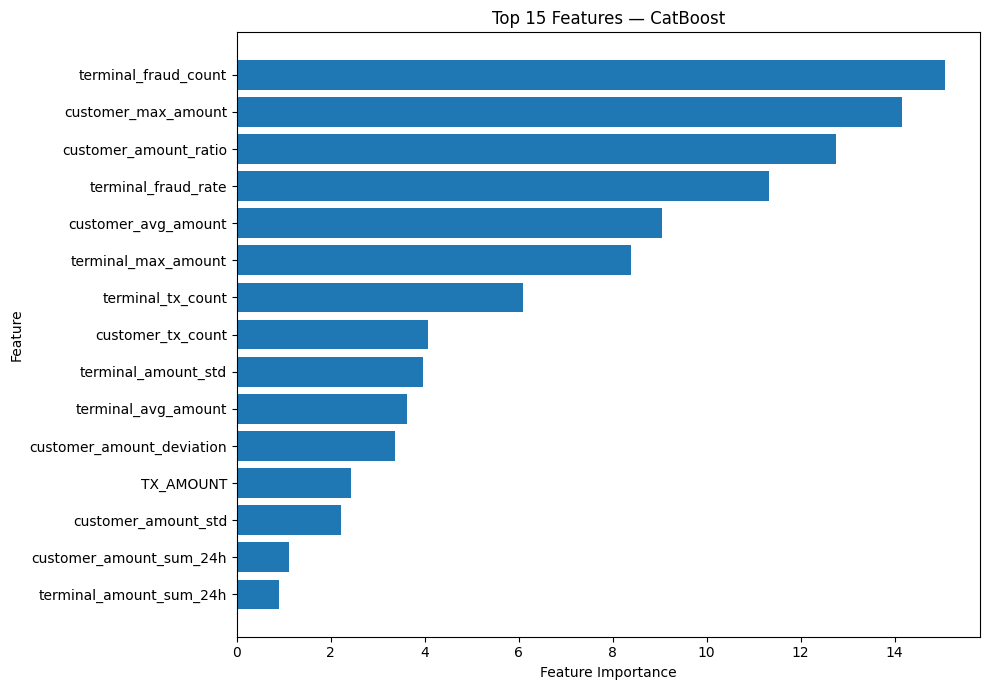

In [129]:
# ============================================================
# FEATURE IMPORTANCE PLOT
# ============================================================

import matplotlib.pyplot as plt

plot_data = (
    top_feature_importance
    .sort_values("importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["feature"],
    plot_data["importance"],
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(
    f"Top {TOP_N_FEATURES} Features — {FINAL_MODEL_NAME}"
)

plt.tight_layout()
plt.show()

## Business Interpretation of Important Features

The final CatBoost model relies mainly on customer-level and terminal-level behavioural features.

The strongest contributors are terminal fraud history, customer transaction amount patterns, and terminal fraud rates. These features indicate that the model is using both historical behaviour and transaction-level deviations when identifying potentially fraudulent activity.

The feature importance results are interpreted together with the error analysis to understand whether the model's decision drivers are aligned with meaningful fraud patterns.

In [130]:
# ============================================================
# TOP FEATURES — BUSINESS INTERPRETATION
# ============================================================

top_features = (
    feature_importance
    .head(10)
    .copy()
)

top_features

,feature,importance
0,terminal_fraud_count,15.062867
1,customer_max_amount,14.154819
2,customer_amount_ratio,12.751988
3,terminal_fraud_rate,11.329702
4,customer_avg_amount,9.056368
5,terminal_max_amount,8.395463
6,terminal_tx_count,6.095360
7,customer_tx_count,4.064460
8,terminal_amount_std,3.964606
9,terminal_avg_amount,3.616090


### Key Model Drivers

The most important features are:

- `terminal_fraud_count` — historical fraud activity associated with the terminal.
- `customer_max_amount` — unusually large historical customer transactions.
- `customer_amount_ratio` — difference between the current transaction and the customer's usual spending pattern.
- `terminal_fraud_rate` — historical fraud frequency associated with the terminal.
- `customer_avg_amount` — customer's typical transaction amount.
- `terminal_max_amount` — maximum historical transaction amount for the terminal.

These features suggest that fraud detection is driven primarily by behavioural history rather than by the transaction amount alone.

## Fraud vs Legitimate Transaction Behaviour

Feature importance shows which variables are important to the model, but it does not describe the actual behaviour of fraudulent transactions.

To complement the model-level interpretation, the key features are compared between legitimate and fraudulent transactions in the test set.

In [131]:
# ============================================================
# FRAUD VS LEGITIMATE FEATURE COMPARISON
# ============================================================

comparison_features = [
    "terminal_fraud_count",
    "terminal_fraud_rate",
    "customer_max_amount",
    "customer_amount_ratio",
    "customer_avg_amount",
    "terminal_max_amount",
    "terminal_tx_count",
    "customer_tx_count",
    "customer_amount_deviation",
    "TX_AMOUNT",
]

available_features = [
    feature
    for feature in comparison_features
    if feature in X_test.columns
]

test_feature_comparison = (
    X_test.assign(actual_label=np.asarray(y_test))
    .groupby("actual_label")[available_features]
    .mean()
    .T
    .reset_index()
    .rename(
        columns={
            "index": "feature",
            0: "legitimate_mean",
            1: "fraud_mean",
        }
    )
)

test_feature_comparison

actual_label,feature,legitimate_mean,fraud_mean
0,terminal_fraud_count,1.342072,10.723989
1,terminal_fraud_rate,0.007942,0.061825
2,customer_max_amount,157.948684,244.748771
3,customer_amount_ratio,0.990324,2.237595
4,customer_avg_amount,53.567073,57.028808
5,terminal_max_amount,232.567734,246.217185
6,terminal_tx_count,168.165369,169.930899
7,customer_tx_count,431.603611,435.568905
8,customer_amount_deviation,-0.627292,72.488565
9,TX_AMOUNT,52.939993,129.517373


### Interpretation

The comparison highlights how the most important behavioural features differ between legitimate and fraudulent transactions.

Features with large differences between the two classes provide additional evidence that the model is learning meaningful fraud-related patterns rather than relying only on the transaction amount.

This analysis is descriptive and is used to support model interpretation; it does not imply that a feature is independently causal for fraud.

## Final Model Findings

The final CatBoost model combines predictive performance with business-oriented threshold selection.

The analysis shows that fraudulent transactions differ from legitimate transactions across several behavioural signals, particularly terminal fraud history, customer spending deviation, transaction amount, and customer amount ratio.

These findings support the use of behavioural and historical transaction features as important signals for fraud detection.

## Business Recommendations

The model results suggest three practical actions for a fraud-monitoring system:

1. Prioritize transactions associated with terminals showing stronger historical fraud activity.
2. Monitor transactions that deviate substantially from a customer's normal spending behaviour.
3. Use the selected operating threshold to balance fraud detection against unnecessary customer friction.

The final model should therefore be treated as a decision-support component rather than an isolated prediction model.

In [132]:
# ============================================================
# FINAL BUSINESS SUMMARY
# ============================================================

business_summary = pd.DataFrame(
    {
        "finding": [
            "Terminal fraud history is a major fraud signal.",
            "Fraudulent transactions show stronger customer spending deviations.",
            "Fraudulent transactions tend to have higher transaction amounts.",
            "The operating threshold should reflect business fraud and customer-friction costs.",
        ]
    }
)

business_summary

,finding
0,Terminal fraud history is a major fraud signal.
1,Fraudulent transactions show stronger customer...
2,Fraudulent transactions tend to have higher tr...
3,The operating threshold should reflect busines...


## Conclusion

The final fraud detection pipeline evaluates candidate models using predictive performance, business cost, threshold behaviour, and sensitivity analysis.

CatBoost was selected as the final champion and evaluated once on the untouched test set. The final analysis shows that the model captures meaningful customer and terminal-level behavioural patterns associated with fraudulent transactions.

The project demonstrates an end-to-end fraud detection workflow from feature engineering and model selection to threshold optimization, business evaluation, error analysis, and model interpretation.

In [133]:
from pathlib import Path

MODEL_PATH = Path("../models/catboost_fraud_model.cbm")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

catboost_model.save_model(str(MODEL_PATH))

print(f"Model saved to: {MODEL_PATH}")

Model saved to: ..\models\catboost_fraud_model.cbm


In [134]:

from pathlib import Path

from app.models.final_model import get_final_model_metadata
from app.models.model_io import save_model


artifacts_dir = Path("../artifacts")

model_metadata = get_final_model_metadata()
model_metadata.update(
    {
        "features": list(X_train.columns),
        "training_records": len(X_train),
        "test_records": len(X_test),
    }
)

saved_artifacts = save_model(
    model=catboost_model,
    metadata=model_metadata,
    model_dir=artifacts_dir,
    model_filename="fraud_risk_model.joblib",
    metadata_filename="model_metadata.json",
)

print("Final CatBoost production artifacts saved successfully.")
print(f"Model: {saved_artifacts['model_path']}")
print(f"Metadata: {saved_artifacts['metadata_path']}")



Final CatBoost production artifacts saved successfully.
Model: ..\artifacts\fraud_risk_model.joblib
Metadata: ..\artifacts\model_metadata.json


## Portfolio Analysis

The final CatBoost model has been selected, evaluated on the untouched test set, and saved as the production model.

The remaining analysis focuses on the key results that communicate model quality, decision-threshold behavior, business cost, interpretability, and final test performance.

In [135]:
plots_dir = PROJECT_ROOT / "assets" / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

print(f"Plots directory: {plots_dir}")

Plots directory: C:\AI\fraud-risk-intelligence-platform\assets\plots


## Model Performance and Final Champion Visualization

The final evaluation results are visualized using the same validation outputs used during model selection.

Three plots are included:

* **Model comparison:** compares business-viable candidates using validation PR-AUC.
* **Threshold analysis:** shows how CatBoost precision, recall, and F1-score change with the operating threshold.
* **Feature importance:** highlights the main behavioural features used by the final CatBoost model.

The plots are generated directly from the existing evaluation DataFrames, so no metrics are manually recreated. The selected CatBoost configuration remains unchanged.


## CatBoost Business Cost Analysis

False negatives are assigned a higher cost than false positives because missed fraud can have a larger financial impact.

The business-cost analysis evaluates the validation thresholds using the agreed cost assumptions:

- False positive cost: 5
- False negative cost: 100

This analysis helps distinguish predictive performance from operational cost.

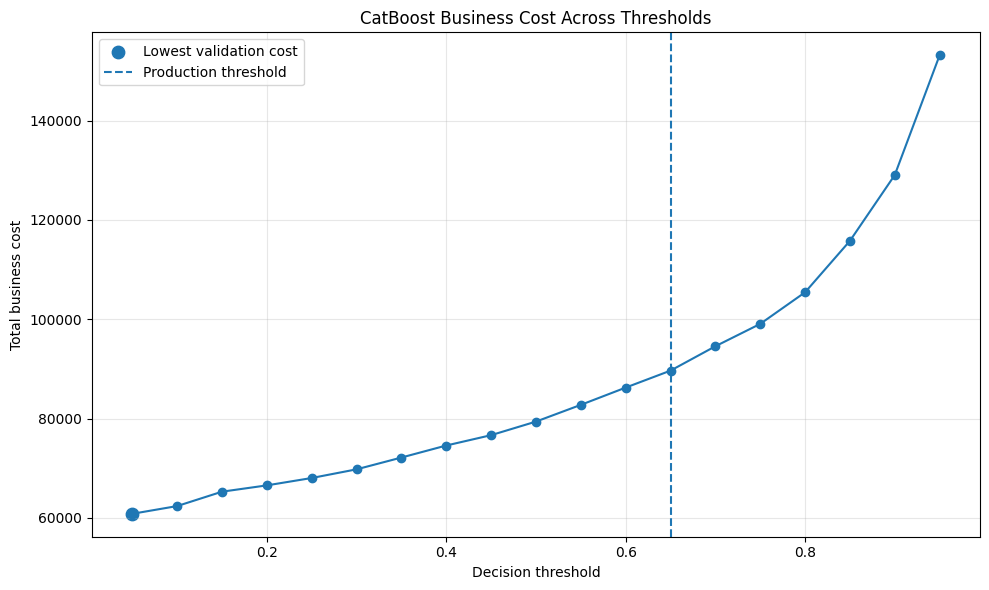

In [150]:
best_business_row = catboost_business_threshold_results.loc[
    catboost_business_threshold_results["total_cost"].idxmin()
]

plt.figure(figsize=(10, 6))

plt.plot(
    catboost_business_threshold_results["threshold"],
    catboost_business_threshold_results["total_cost"],
    marker="o",
)

plt.scatter(
    best_business_row["threshold"],
    best_business_row["total_cost"],
    s=80,
    label="Lowest validation cost",
)

plt.axvline(
    final_threshold,
    linestyle="--",
    label="Production threshold",
)

plt.xlabel("Decision threshold")
plt.ylabel("Total business cost")
plt.title("CatBoost Business Cost Across Thresholds")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    plots_dir / "business_cost_analysis.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

The lowest validation business cost and the final production threshold are shown separately.

The production threshold remains the model-selection decision rather than simply choosing the threshold with the lowest validation cost.

## Final Test Confusion Matrix

The confusion matrix summarizes the final CatBoost performance on the untouched test set using the frozen production threshold.

It shows the balance between correctly identified fraud, missed fraud, and legitimate transactions incorrectly flagged for review.

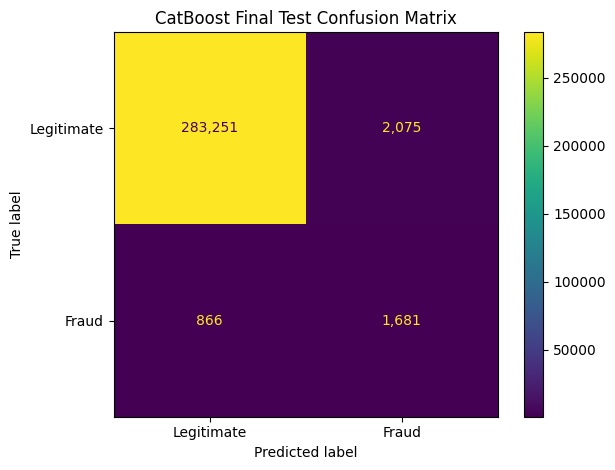

In [149]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

test_predictions = error_analysis["predicted_label"].to_numpy()

confusion_matrix_values = confusion_matrix(
    y_test,
    test_predictions,
)

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_values,
    display_labels=["Legitimate", "Fraud"],
).plot(
    values_format=",d",
)

plt.title("CatBoost Final Test Confusion Matrix")
plt.tight_layout()

plt.savefig(
    plots_dir / "confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## CatBoost Feature Importance

Feature importance is used to understand which engineered signals contribute most strongly to the final model's predictions.

These values support model interpretation but should not be treated as evidence of causality.

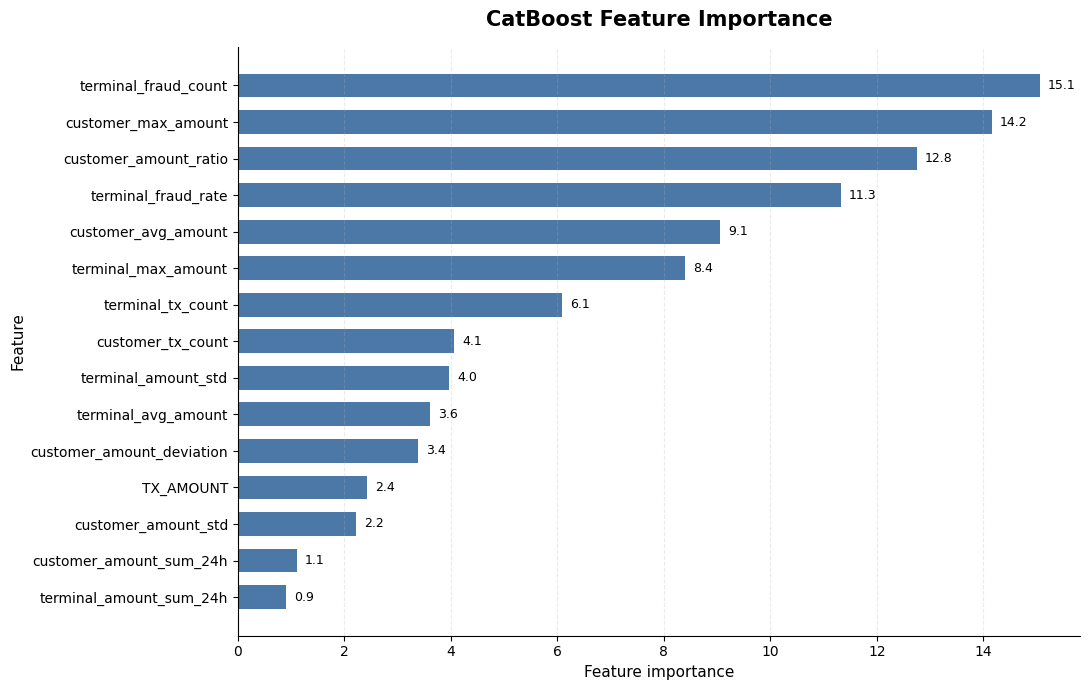

In [155]:
feature_importance_plot = (
    catboost_top_features
    .sort_values(
        "importance",
        ascending=True,
    )
    .copy()
)

plt.figure(figsize=(11, 7))

bars = plt.barh(
    feature_importance_plot["feature"],
    feature_importance_plot["importance"],
    color="#4C78A8",
    height=0.65,
)

for bar, value in zip(
    bars,
    feature_importance_plot["importance"],
):
    plt.text(
        value + feature_importance_plot["importance"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}",
        va="center",
        fontsize=9,
    )

plt.xlabel(
    "Feature importance",
    fontsize=11,
)

plt.ylabel(
    "Feature",
    fontsize=11,
)

plt.title(
    "CatBoost Feature Importance",
    fontsize=15,
    fontweight="bold",
    pad=15,
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25,
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    plots_dir / "catboost_feature_importance.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Final Precision-Recall Curve

The precision-recall curve shows the relationship between fraud detection recall and precision across probability thresholds.

It is particularly useful for imbalanced classification because it focuses on performance for the positive fraud class.

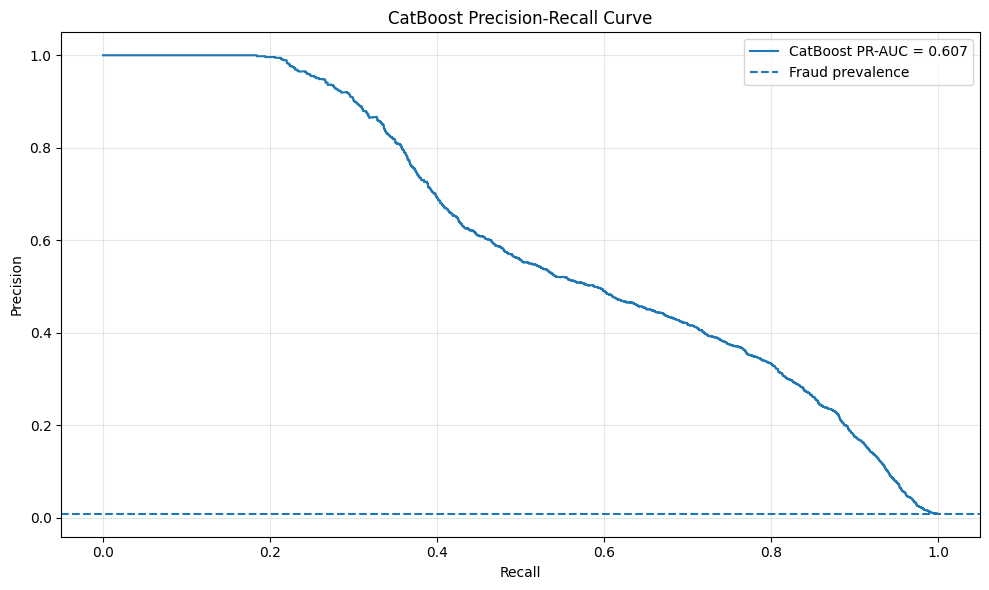

In [147]:
from sklearn.metrics import precision_recall_curve

test_probabilities = error_analysis["fraud_probability"].to_numpy()

precision_values, recall_values, _ = precision_recall_curve(
    y_test,
    test_probabilities,
)

fraud_rate = y_test.mean()

plt.figure(figsize=(10, 6))

plt.plot(
    recall_values,
    precision_values,
    label=f"CatBoost PR-AUC = {final_test_results['pr_auc']:.3f}",
)

plt.axhline(
    fraud_rate,
    linestyle="--",
    label="Fraud prevalence",
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("CatBoost Precision-Recall Curve")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    plots_dir / "precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

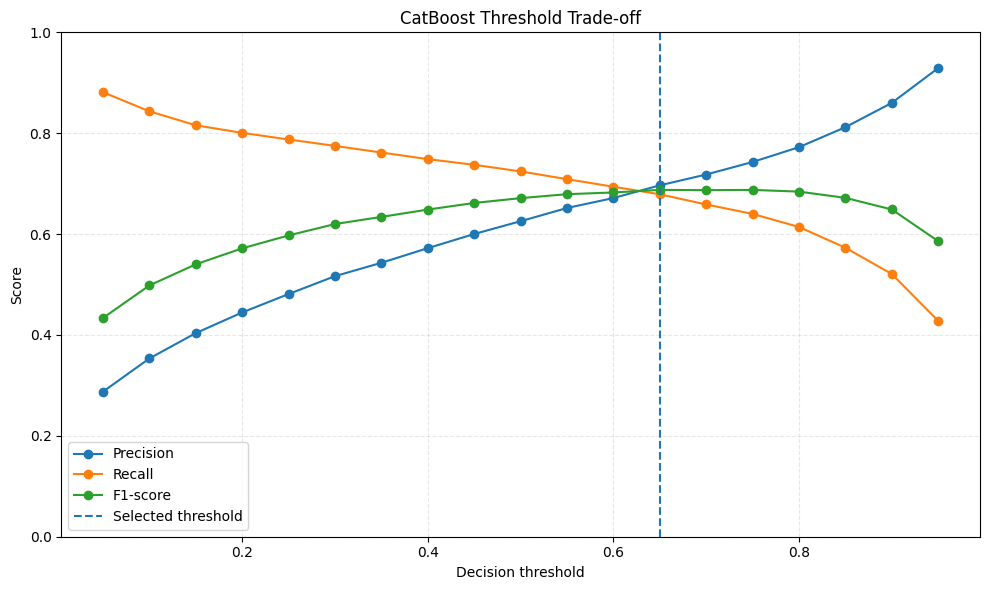

In [151]:
plt.figure(figsize=(10, 6))

plt.plot(
    catboost_threshold_results["threshold"],
    catboost_threshold_results["precision"],
    marker="o",
    label="Precision",
)

plt.plot(
    catboost_threshold_results["threshold"],
    catboost_threshold_results["recall"],
    marker="o",
    label="Recall",
)

plt.plot(
    catboost_threshold_results["threshold"],
    catboost_threshold_results["f1_score"],
    marker="o",
    label="F1-score",
)

plt.axvline(
    final_champion["best_performance_threshold"],
    linestyle="--",
    label="Selected threshold",
)

plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title("CatBoost Threshold Trade-off")
plt.ylim(0, 1)

plt.grid(
    linestyle="--",
    alpha=0.3,
)

plt.legend()
plt.tight_layout()

plt.savefig(
    plots_dir / "catboost_threshold_tradeoff.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

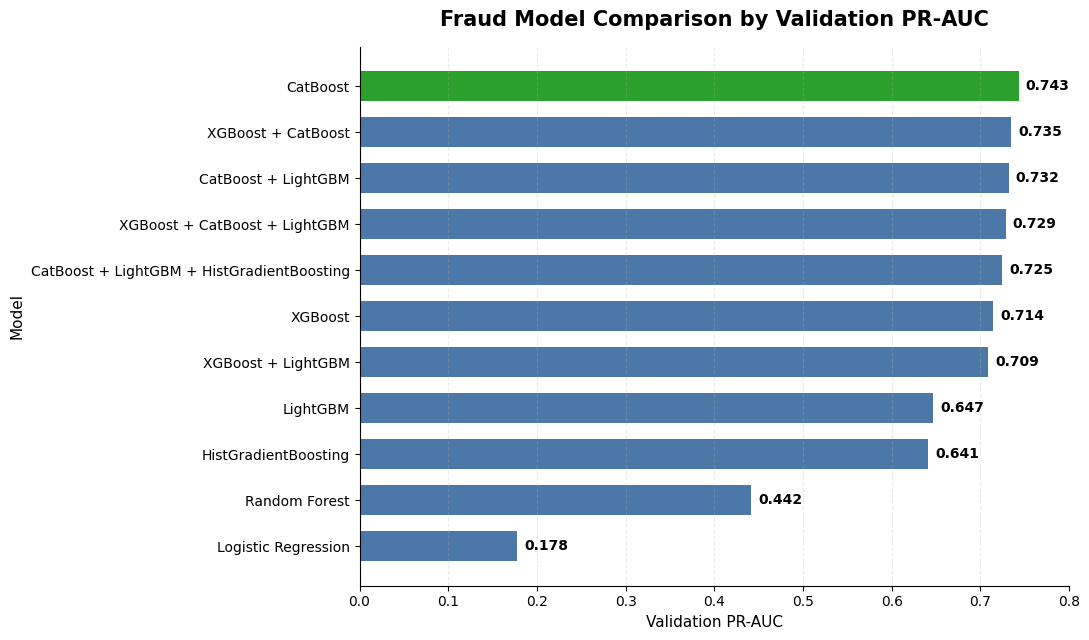

In [154]:
model_comparison_plot = (
    final_candidate_comparison[
        [
            "model",
            "best_pr_auc",
        ]
    ]
    .sort_values(
        "best_pr_auc",
        ascending=True,
    )
    .copy()
)

plt.figure(figsize=(11, 6.5))

bar_colors = [
    "#4C78A8" if model != "CatBoost" else "#2CA02C"
    for model in model_comparison_plot["model"]
]

bars = plt.barh(
    model_comparison_plot["model"],
    model_comparison_plot["best_pr_auc"],
    color=bar_colors,
    height=0.65,
)

for bar, value in zip(
    bars,
    model_comparison_plot["best_pr_auc"],
):
    plt.text(
        value + 0.008,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=10,
        fontweight="bold",
    )

plt.xlabel(
    "Validation PR-AUC",
    fontsize=11,
)

plt.ylabel(
    "Model",
    fontsize=11,
)

plt.title(
    "Fraud Model Comparison by Validation PR-AUC",
    fontsize=15,
    fontweight="bold",
    pad=15,
)

plt.xlim(0, 0.80)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25,
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    plots_dir / "model_comparison_pr_auc.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Final Model Summary

CatBoost was selected as the final fraud-risk classifier after comparing predictive performance, threshold behavior, business cost, and model robustness.

The final operating threshold was fixed at 0.65 before evaluating the untouched test set.

The model and its metadata have been saved as production artifacts, while the key evaluation results have been exported as portfolio-ready visuals.